Luigi VUACHET – luigi.vuachet.etu@univ-lille.fr
Kobla LEGBEDJE – kobla.legbedje.etu@univ-lille.fr

<div style="text-align: center; font-size: 1.8em; font-weight: bold; margin-top: 20px; margin-bottom: 20px;">
    <h2>Projet 1 : Traitement du Signal - Échantillonnage et Filtrage</h2>
</div>

---

# **Partie 1 : Échantillonnage**

L’échantillonnage consiste à convertir un signal continu en une série de valeurs discrètes. Pour cela, nous utilisons :  
- Une **période d'échantillonnage** $t_e$ définissant les instants $t_k = k \cdot t_e$, où $k$ est un entier.  
- Une **fréquence d'échantillonnage** $f_e = \frac{1}{t_e}$.  

Nous obtenons un nombre fini $N$ d'échantillons sur l’intervalle $[0, T]$, avec $t_e = \frac{T}{N}$. Ce processus est clé pour convertir un signal continu en numérique, facilitant son traitement dans les systèmes électroniques.

---

## **1. Fonction d’échantillonnage**

La fonction `Echantillonnage(T, u, N)` génère des échantillons d’un signal continu $u(t)$ sur $[0, T]$ en $N$ points.  

### **Étapes :**
1. Entrées :
   - $T$ : durée d'échantillonnage.
   - $u(t)$ : signal continu.
   - $N$ : nombre d'échantillons.
2. Calcul des instants $t_k$ :  
$$
t_k = \frac{k \cdot T}{N}, \quad k = 0, 1, \dots, N-1
$$
3. Évaluation des échantillons : $u_k = u(t_k)$.
4. Visualisation : tracé du signal discret.

Cette méthode permet de modéliser efficacement un signal pour son analyse et son traitement.


In [ ]:
# Projet 1 Module pour traitement du signal - échantillonnage et filtrage
# importation des donnée

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import *
import scipy.signal as signal
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Paramètre pour la fonction u(t)
a = 20000

# Définition de la fonction u(t)
def u(t):
    return np.cos(2 * np.pi * a * (1 - t ** 2))

# Fonction d'échantillonnage
def Echantillonnage(T, u, N, title=""):
    Te = T / N  # Période d'échantillonnage
    t = np.linspace(0, T, N)  # Génère N points uniformément espacés entre 0 et T
    echant = u(t)  # Applique la fonction u(t) pour obtenir les échantillons

    # Représentation graphique
    plt.figure(figsize=(18, 4))
    plt.plot(t, echant, label='Échantillons de u(t)')
    plt.xlabel('t')
    plt.ylabel('u(t)')
    plt.title("Échantillonnage de la fonction u(t)"+title)
    plt.grid()
    plt.legend()
    plt.show()

    return echant  # Retourne les échantillons pour la question 2


## **2. Spectre des échantillons**

Le spectre des échantillons est obtenu via la **Transformée de Fourier Discrète (DFT)** :  
- La résolution spectrale est $ \frac{1}{T} $, où $T$ est la période d'échantillonnage.  
- Les fréquences couvrent l'intervalle de $0$ à la **fréquence d’échantillonnage** $f_e$, avec une symétrie autour de la **fréquence de Nyquist** $f_n = \frac{f_e}{2}$.  

La fonction `RepresentationSpectre(echant, T)` calcule et affiche :  
- Le spectre des amplitudes des échantillons.  
- La fréquence de Nyquist pour une meilleure visualisation.

## **3) Essais Numériques avec la fonction $u(t) = \cos(2 \pi a (1 - t^2))$**

Appliquons désormais les fonctions précédantes à :
$$u(t) = \cos(2 \pi a (1 - t^2))$$
avec $a = 20000$, $T = 0.1$ et $N = 2000$.
Nous testons ensuite d'autres valeurs intéressantes des paramètres $N$ et $a$ afin d'observer l'impact de ces variations sur l'échantillonnage et le spectre du signal.


Vérification des graphiques avec d'autres valeurs de a et N

In [ ]:
# Fonction pour afficher le spectre
def RepresentationSpectre(echant, T, title=""):
    N = len(echant)
    f_e = N / T
    f_n = f_e / 2

    frequence = np.arange(N) / T
    DFT = np.fft.fft(echant)
    spectre = np.abs(DFT)

    plt.figure(figsize=(16, 6))
    plt.plot(frequence, spectre, color="royalblue")
    plt.axvline(x=f_n, color="red", linestyle="--", label=r"Fréquence de Nyquist")
    plt.title("Spectre des échantillons"+title)
    plt.xlabel("Fréquence")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()

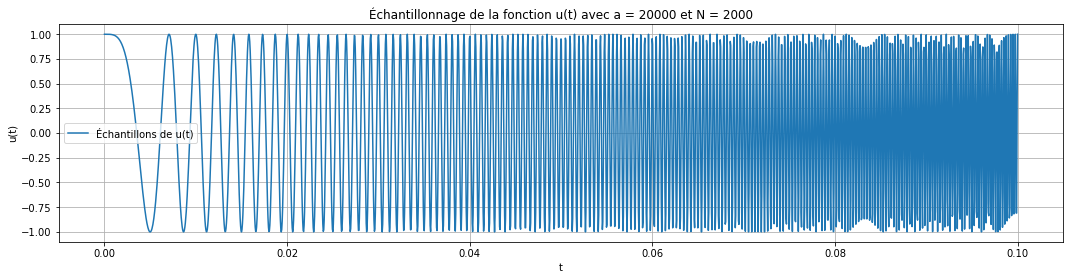

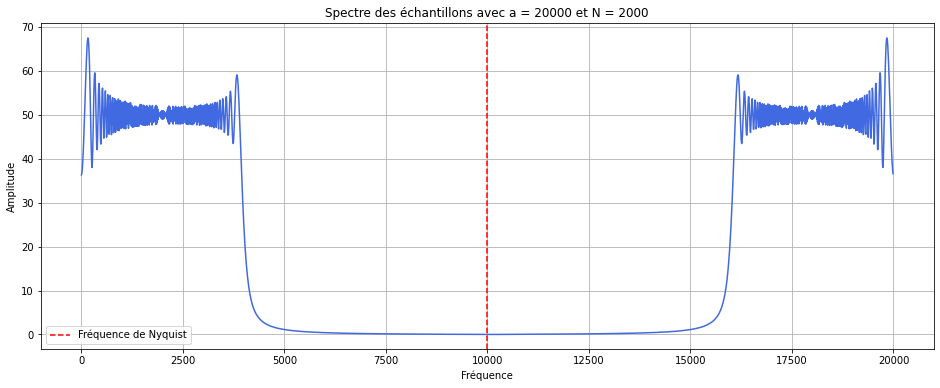

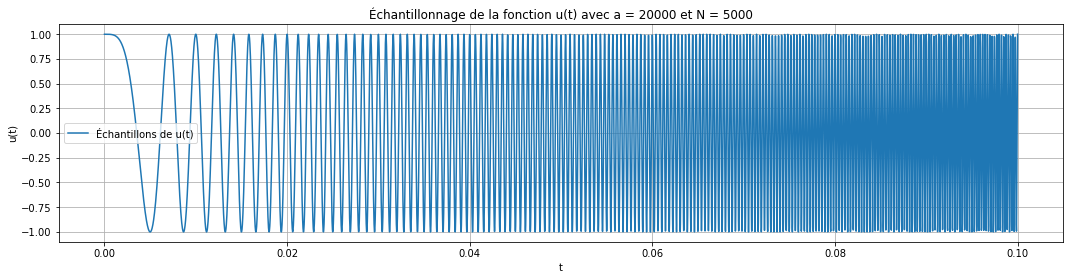

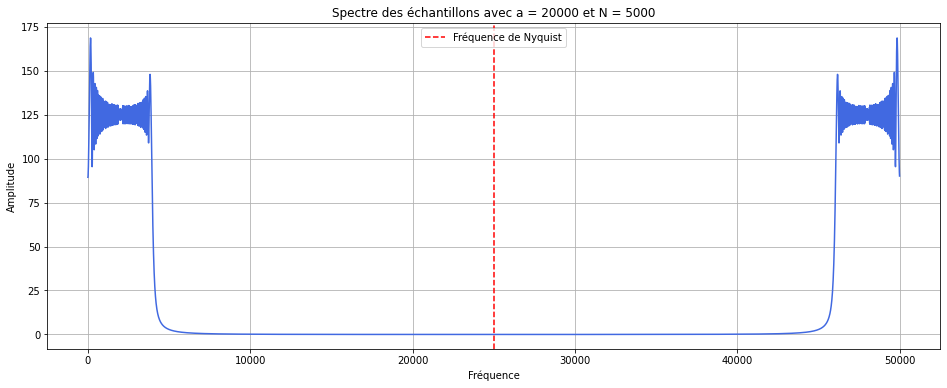

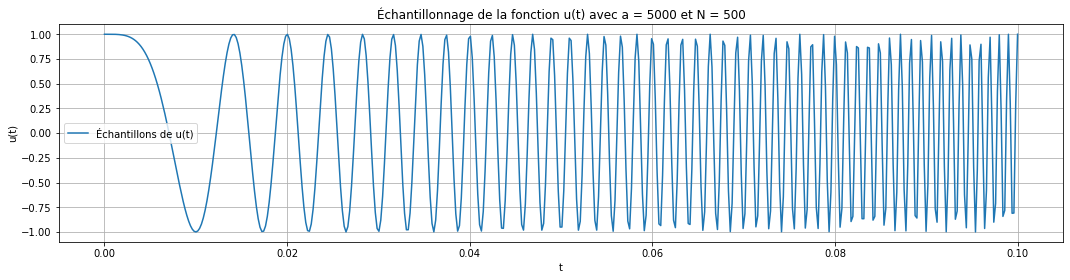

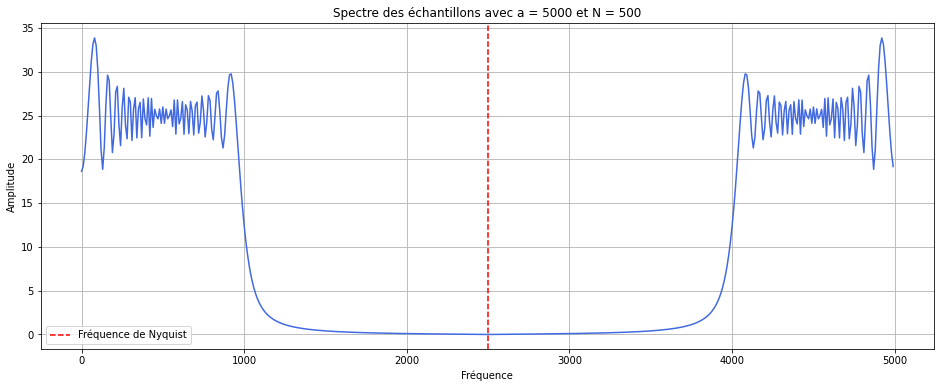

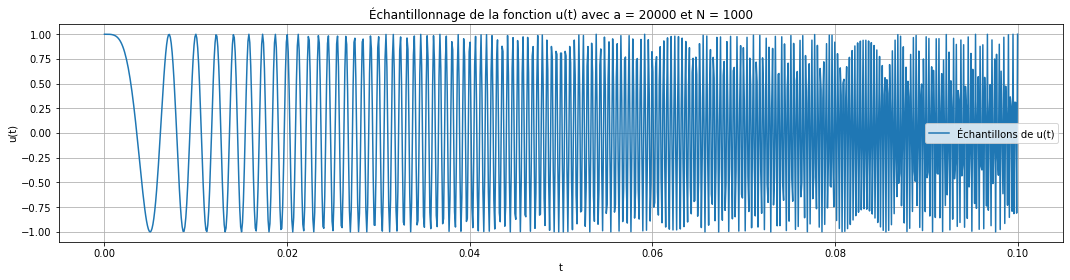

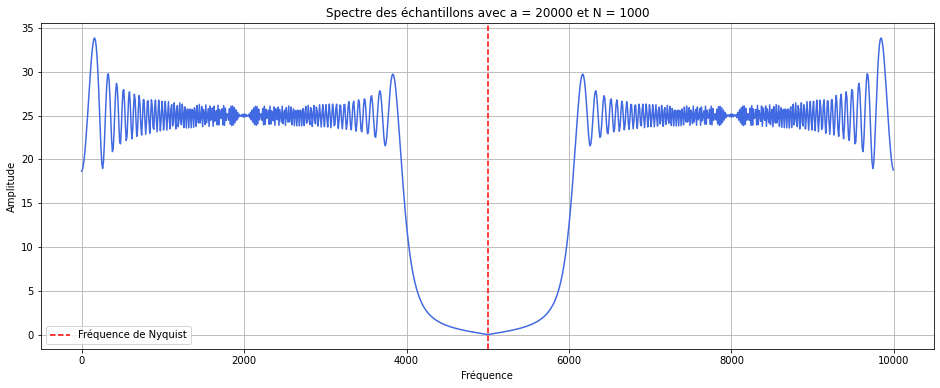

In [ ]:
T = 0.1
N = 2000

# Essais avec différentes valeurs
for a, N in [(20000,2000),(20000, 5000), (5000, 500), (20000, 1000)]:
    echantillon = Echantillonnage(T, u, N, " avec a = "+str(a)+ " et N = "+str(N))
    RepresentationSpectre(echantillon, T, " avec a = "+str(a)+ " et N = "+str(N))


 En exécutant la fonction  Echantillonnage, nous obtenons  une représentation temporelle de la fonction u(t).

Spectre : La fonction RepresentationSpectre montre un pic dans le spectre autour de la fréquence principale, en fonction de la valeur de a.


### **4. Illustration du théorème de Shannon**

Le théorème de Shannon impose que la fréquence d’échantillonnage $f_e$ dépasse le double de la fréquence maximale $f_{\text{max}}$ pour éviter l'aliasing et assurer une reconstruction fidèle :  
$$
f_e > 2 \cdot f_{\text{max}}
$$

Dans notre cas, avec $f_{\text{max}} = 6000$, la fréquence minimale est :  
$$
f_e = 2 \cdot 6000 = 12000 \, \text{Hz}
$$

Pour valider cela, nous testerons différentes valeurs de $f_e$.  
- **Si $f_e > 12000$ :** reconstruction fidèle.  
- **Si $f_e \leq 12000$ :** aliasing et déformation du signal.  


In [ ]:
def signal(t):
    return np.cos(2 * np.pi * a * (1 - t**2))

In [ ]:
# Fonction d'échantillonnage
def display_shannon(T, signal, f_e,title=""):

    N = int(T * f_e)
    t = np.linspace(0, T, N)
    echant = signal(t)

    RepresentationSpectre(echant, T,title)

    return echant

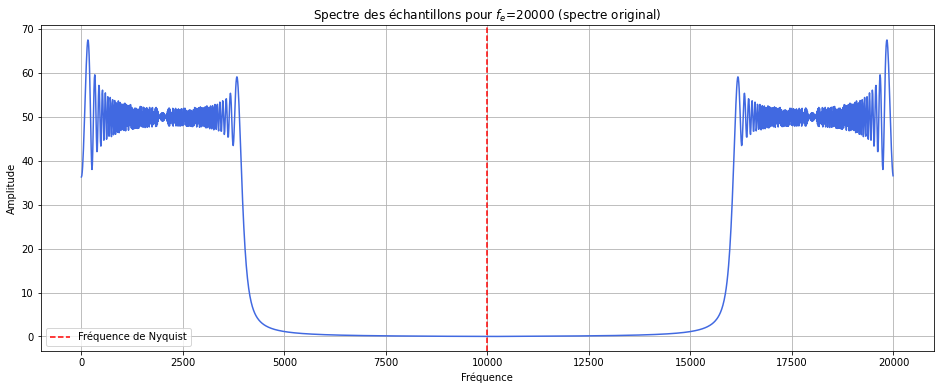

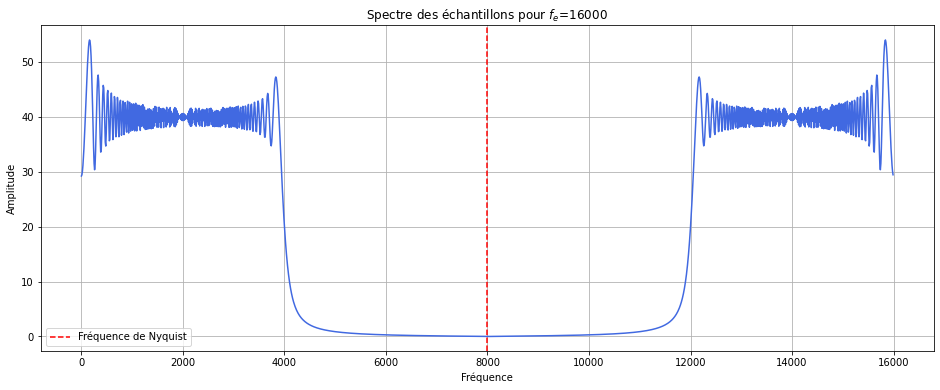

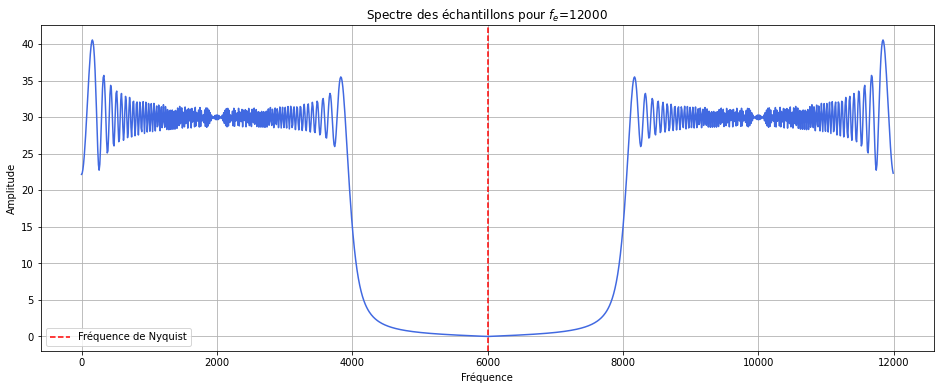

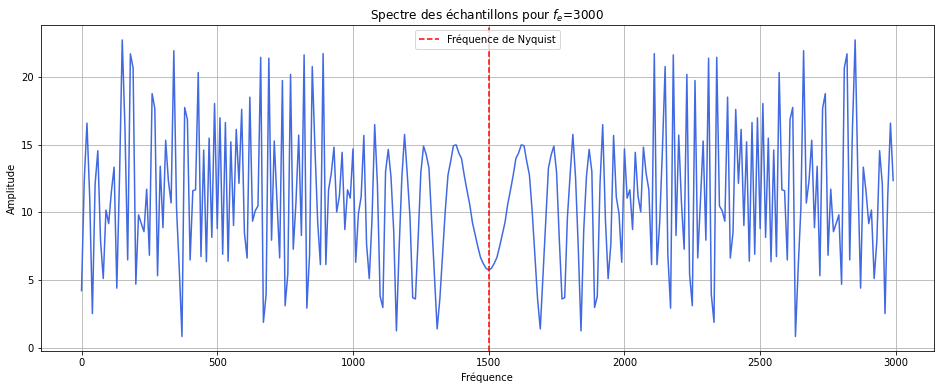

In [ ]:
a = 20000
T = 0.1

fe_list = [20000, 16000, 12000,3000]
for f_e in fe_list:
    add=""
    if(f_e==20000):
        add=" (spectre original)"
    display_shannon(T, signal, f_e, " pour $f_e$="+str(f_e)+add)

### **Analyse des fréquences d’échantillonnage**

Nous avons testé trois fréquences d’échantillonnage pour observer leur impact sur le signal :  

- **$f_e = 3000$ Hz (< $2 \cdot f_{\text{max}}$)** :  
  L’aliasing est clairement visible. La fréquence d’échantillonnage étant insuffisante, certaines fréquences du signal se replient, entraînant une distorsion et une perte d’information.  

- **$f_e = 12000$ Hz (= $2 \cdot f_{\text{max}}$)** :  
  Cette fréquence respecte la condition de Nyquist-Shannon. Le signal est échantillonné correctement, sans aliasing, et peut être fidèlement reconstruit. Ce cas représente la limite minimale où le théorème de Shannon est valide.  

- **$f_e = 16000$ Hz (> $2 \cdot f_{\text{max}}$)** :  
  Avec cette fréquence plus élevée, le signal échantillonné est parfaitement fidèle, sans perte d’information. Bien que cela améliore la résolution fréquentielle, il n'y a pas de gain significatif par rapport à $f_e = 12000$ Hz en termes de reconstruction du signal.  


## **5) Illustration de la Condition de Shannon en cas de sous echantillonnage**

Pour illustrer cette condition, nous allons :
 - Calculer et afficher le signal échantillonné avec une fréquence fe qui     respecte la condition de Shannon.
 - Échantillonner de nouveau le signal avec une fréquence plus basse (par exemple en utilisant N=300 tout en conservant T=0.1), ce qui devrait produire un sous-échantillonnage et donc une perte d'information.


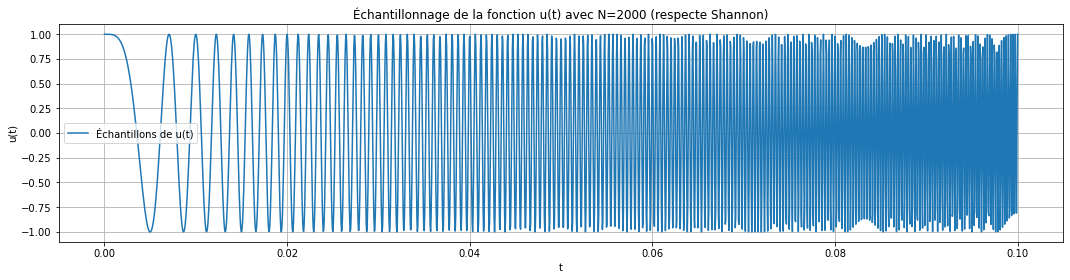

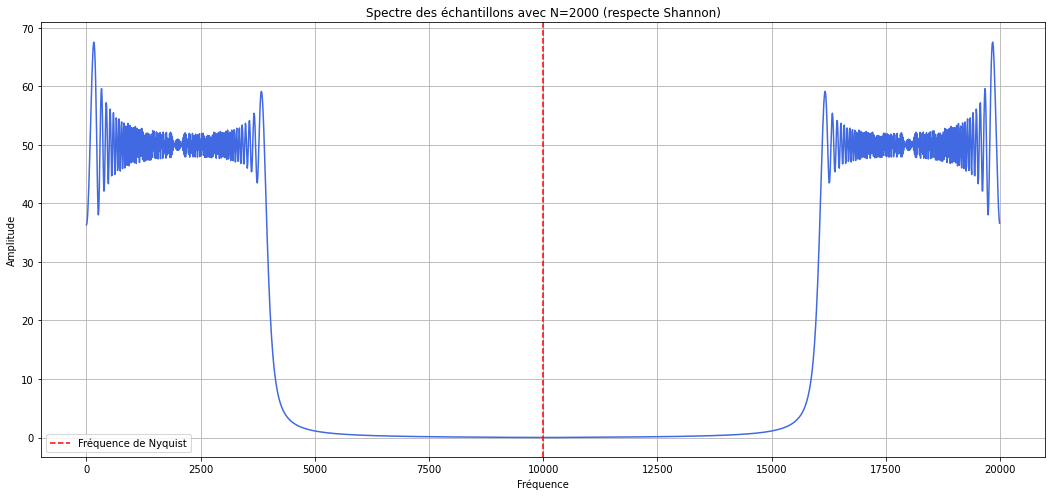

In [ ]:
# Échantillonnage respectant la condition de Shannon (avec N=2000)
echant_2000 = Echantillonnage(T, u, 2000, " avec N=2000 (respecte Shannon)")
RepresentationSpectre(echant_2000, T, " avec N=2000 (respecte Shannon)")


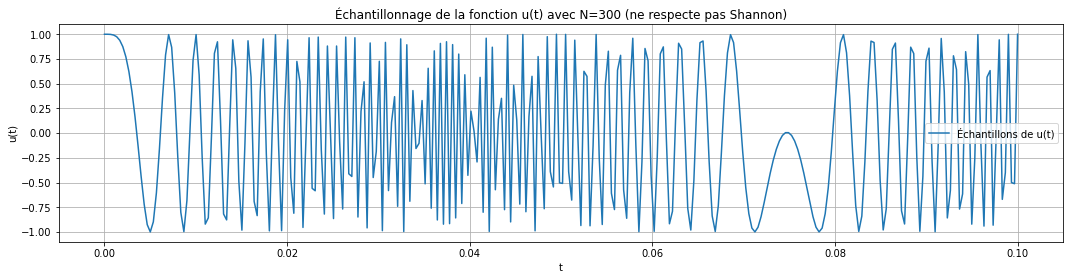

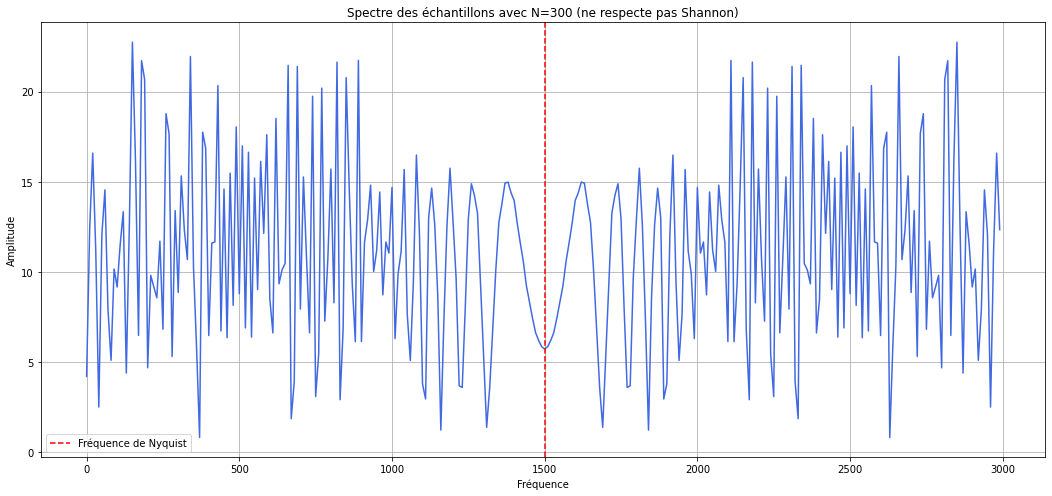

In [ ]:
# Échantillonnage ne respectant pas la condition de Shannon (avec N=300)
N_low = 300
echant_300 = Echantillonnage(T, u, N_low," avec N=300 (ne respecte pas Shannon)")
RepresentationSpectre(echant_300, T," avec N=300 (ne respecte pas Shannon)")


Pour N=2000 : Cet échantillonnage respecte la condition de Shannon, et le spectre montre des composantes harmonieuses sans aliasing tandisque pour  N=300: Dans ce cas, la fréquence d'échantillonnage est réduite, et on à  un phénomène de sous-échantillonnage dans le spectre, qui  se manifeste par des effets de repliement de bande (aliasing). Le spectre  montre des fréquences fantômes, résultant du non-respect du théorème de Shannon

6-a
Dans cette question, on échantillonne un autre signal, u(t)=sin⁡(2πt), pour deux fréquences d’échantillonnage différentes :
fe1=100 Hz et fe2​=2.234 Hz.

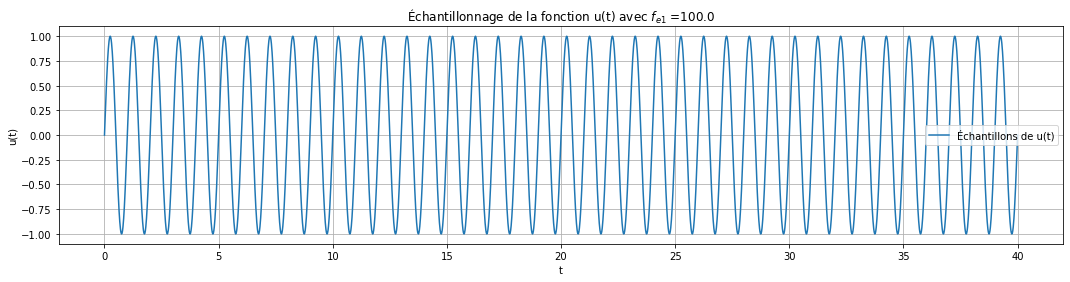

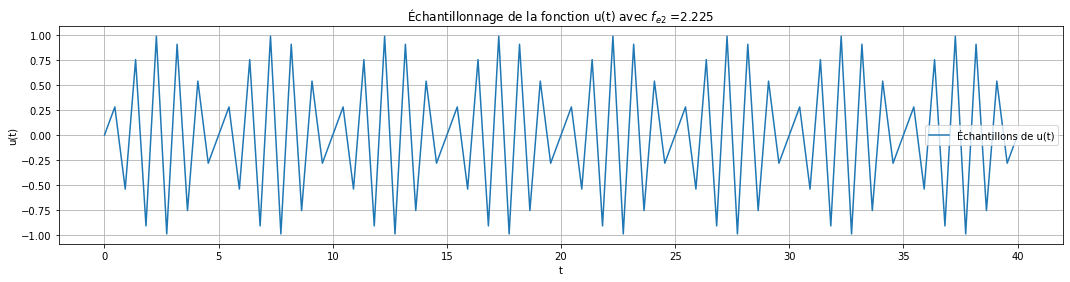

In [ ]:
# Nouvelle fonction u(t) pour cette question
def u2(t):
    return np.sin(2 * np.pi * t)

# Échantillonnage avec une fréquence élevée fe1 = 100 Hz
fe1 = 100
T = 40  # Période de 1 seconde
N1 = int(T*fe1 ) # Correspond à fe1 = 100 Hz
echant1 = Echantillonnage(T, u2, N1," avec $f_{e1}$ ="+str( 1/Te1))
Te1 = T / N1  # Période d'échantillonnage pour fe1

# Échantillonnage avec une fréquence basse fe2 = 2.234 Hz
fe2 = 2.234
N2 = int(T * fe2)  # Nombre d'échantillons correspondant à fe2 = 2.234 Hz
echant2 = Echantillonnage(T, u2, N2," avec $f_{e2}$ ="+str( 1/Te2))
Te2 = T / N2  # Période d'échantillonnage pour fe2

### **Analyse des fréquences $f_{e1}$ et $f_{e2}$**

- **$f_{e1} = 100$ Hz** :  
  Cette fréquence dépasse largement la limite de Shannon ($f_{e1} \gg 2 \cdot f_{\text{max}}$). Les échantillons reproduisent parfaitement le signal continu, sans perte d’information.  

- **$f_{e2} = 2.234$ Hz** :  
  Proche de la limite de Nyquist fe2 est légérement supérieur à 1Hz la fréquence max.
Une fréquence d’échantillonnage juste au-dessus de la limite de Shannon peut être insuffisante pour garantir une reconstruction fidèle et précise du signal.

6-b Représentation des échantillons reliés

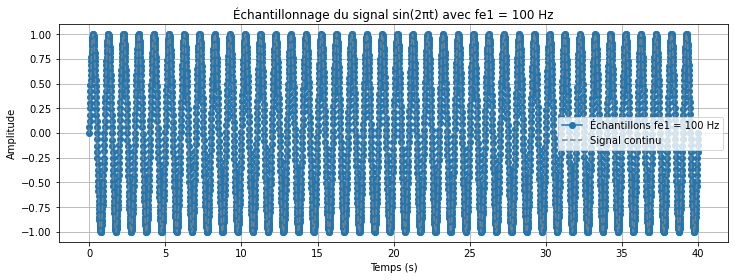

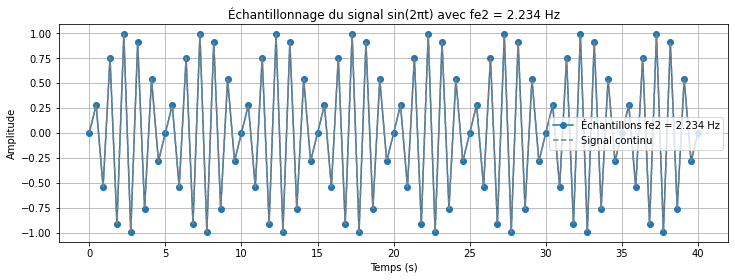

In [ ]:
# Connexion des échantillons pour fe1
plt.figure(figsize=(12, 4))
t1 = np.linspace(0, T, N1)
plt.plot(t1, echant1, marker='o', label='Échantillons fe1 = 100 Hz')
plt.plot(t1, u2(t1), linestyle='--', color='gray', label='Signal continu')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Échantillonnage du signal sin(2πt) avec fe1 = 100 Hz')
plt.grid()
plt.show()

# Connexion des échantillons pour fe2
plt.figure(figsize=(12, 4))
t2 = np.linspace(0, T, N2)
plt.plot(t2, echant2, marker='o', label='Échantillons fe2 = 2.234 Hz')
plt.plot(t2, u2(t2), linestyle='--', color='gray', label='Signal continu')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Échantillonnage du signal sin(2πt) avec fe2 = 2.234 Hz')
plt.grid()
plt.show()


La fonction interpolée à partir des échantillons avec fe2​ s'écarte considérablement du signal original u(t).
 Cela illustre qu'en dépit du respect du théorème de Shannon, une reconstruction peut subir une perte importante d'information et une distorsion notable.



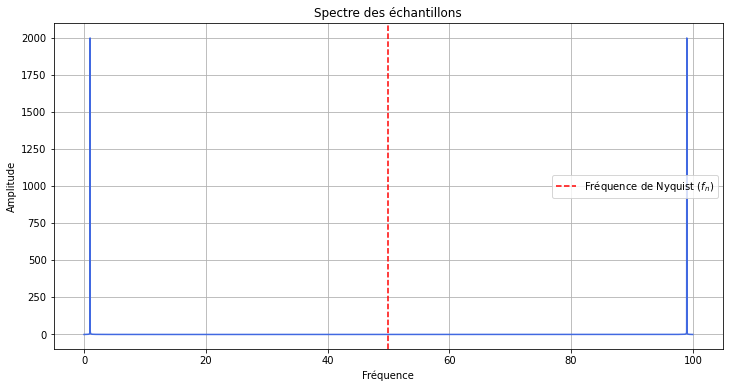

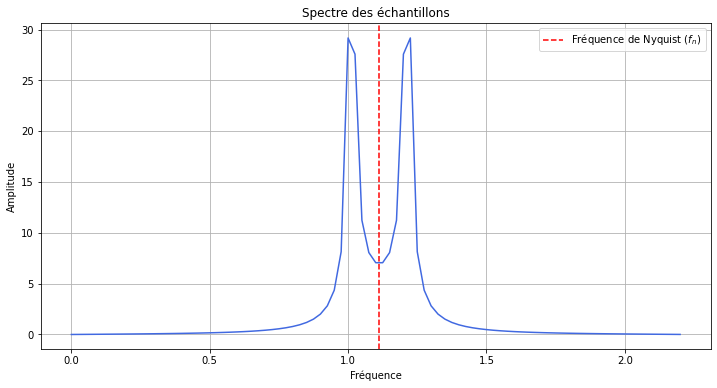

In [ ]:
# reprrésentations des spectres de fe2
RepresentationSpectre(echant2, T)

# Interprétation des pics du spectre (pic en 1hz et 1.234 hz)
**Justification** :Le théorème de Shannon étant vérifié, les échantillons ont conservé les informations présentes dans le signal d'origine, notamment la fréquence principale, sans distorsion majeure.
    

6)-d La representation du signal avec la nouvelle technique

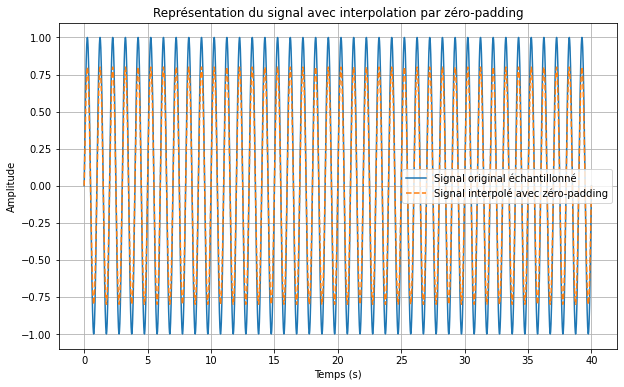

In [ ]:
# Signal original avec la frequence fe1 en utilisant la nouvelle technique
Te = T / N1
t = np.linspace(0, T, N1)

# Transformée de Fourier
spectre = np.fft.fft(echant1)
N_spectre = len(spectre)

# Ajout de zéros dans le spectre pour "interpoler" dans le domaine temporel
nbzero = 1000  # Nombre de zéros à ajouter
spectre_padded = np.concatenate([spectre[:N_spectre//2], np.zeros(nbzero), spectre[N_spectre//2:]])

# Transformée de Fourier Inverse avec le spectre modifié
u_t_padded = np.fft.ifft(spectre_padded)

# Nouvelle échelle de temps correspondant au signal interpolé
N_new = len(u_t_padded)
t_padded = np.linspace(0, T, N_new)

# Représentation des signaux
plt.figure(figsize=(10, 6))

plt.plot(t, u2(t), label="Signal original échantillonné")
plt.plot(t_padded, u_t_padded.real, label="Signal interpolé avec zéro-padding", linestyle='--')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.title("Représentation du signal avec interpolation par zéro-padding")
plt.legend()
plt.grid(True)
plt.show()


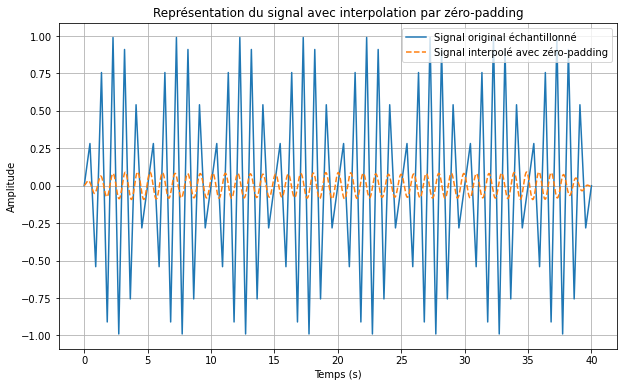

In [ ]:
# Signal original avec la frequence fe1 en utiliasant la nouvelle technique
Te = T / N2
t = np.linspace(0, T, N2)

# Transformée de Fourier
spectre = np.fft.fft(echant2)
N_spectre = len(spectre)

# Ajout de zéros dans le spectre pour "interpoler" dans le domaine temporel
nbzero = 1000  # Nombre de zéros à ajouter
spectre_padded = np.concatenate([spectre[:N_spectre//2], np.zeros(nbzero), spectre[N_spectre//2:]])

# Transformée de Fourier Inverse avec le spectre modifié
u_t_padded = np.fft.ifft(spectre_padded)

# Nouvelle échelle de temps correspondant au signal interpolé
N_new = len(u_t_padded)
t_padded = np.linspace(0, T, N_new)

# Représentation des signaux
plt.figure(figsize=(10, 6))

plt.plot(t, u2(t), label="Signal original échantillonné")
plt.plot(t_padded, u_t_padded.real, label="Signal interpolé avec zéro-padding", linestyle='--')
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.title("Représentation du signal avec interpolation par zéro-padding")
plt.legend()
plt.grid(True)
plt.show()

En ajoutant des zéros dans la DFT, on augmente le nombre de points dans la représentation du signal temporel, ce qui  rend le signal plus lisse et plus continu. On a ainsi obtenir une meilleure approximation du signal original surtout dans le deuxiéme cas ou fe2 est faible.

7) Le repliement de bande

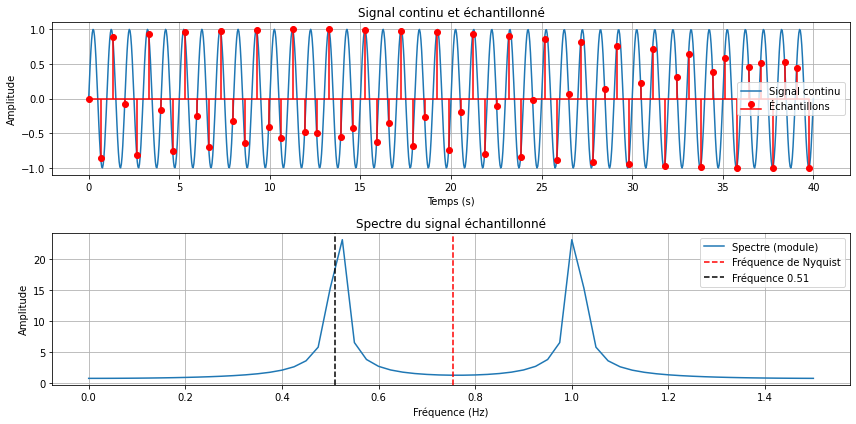

In [ ]:
# Paramètres du signal
T = 40  # Durée en secondes
f_signal = 1  # Fréquence du signal (1 Hz)
f_e = 1.51  # Fréquence d'échantillonnage

# Signal continu
t_continu = np.linspace(0, T, 1000)  # Temps pour le signal continu
u_t = np.sin(2 * np.pi * f_signal * t_continu)  # Signal continu

# Signal échantillonné
n = np.arange(0, T, 1 / f_e)  # Instants d'échantillonnage
u_n = np.sin(2 * np.pi * f_signal * n)  # Échantillons

# Spectre du signal échantillonné
N = len(n)
spectre = np.fft.fft(u_n)
frequences =np.arange(N)*1.0/T

# Représentation temporelle
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_continu, u_t, label="Signal continu")
plt.stem(n, u_n, linefmt='r-', markerfmt='ro', basefmt='r-', label="Échantillons")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.title("Signal continu et échantillonné")
plt.legend()
plt.grid()

# Représentation fréquentielle
plt.subplot(2, 1, 2)
plt.plot(frequences, np.abs(spectre), label="Spectre (module)")
plt.axvline(x=f_e/2, color='r', linestyle='--', label="Fréquence de Nyquist")
plt.axvline(x=0.51, color='black', linestyle='--', label="Fréquence 0.51")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.title("Spectre du signal échantillonné")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()



Le spectre obtenu, altéré par le repliement, ne correspond pas au spectre du signal continu. Les pics sont déplacés à des fréquences incorrectes, entraînant une perte de l'information spectrale originale et rendant une reconstruction fidèle impossible.


# **2. Les filtres**


Nous partons d'un signal analogique $x(t)$ que nous allons échantillonner sur une période $t_e$, pour obtenir un signal numérique $x[n] = x(n \cdot t_e).$

Un filtre RIF, autrement dit à réponse impulsionnelle finie calcule un signal de sortie $y[n]$ donné par :
$$ y[n] = \sum_{k=0}^{N-1} h[k] \cdot x[n-k] \quad \text{avec} \, h[k] \, \text{les coefficients qui définissent le filtre.}$$

Mais aussi, nous considérons la fonction réponse fréquentielle, que nous utiliserons en fonction de $f$ ou de $f/f_e$ et qui est définie par :
$$ H(f/f_e) = \sum_{k=0}^{N-1} h[k] \cdot \exp^{-2 \pi i k f/f_e} \quad \text{avec} \, f/f_e < \frac{1}{2} \; \text{par le théorème de Shannon.}$$

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import random
import scipy
from scipy import signal

##  **1) Implementation de la fonction réponse fréquentielle**

Nous écrivons la fonction réponse fréquentielle qui renvoie le module et l'argument de la fonction définie ci-dessus. Elle prend en entrée un nombre $ nf $ qui correspond au nombre de points de l'intervalle $ [0, 0.5] $, pour lesquels leurs valeurs sont associées à $ f/f_e $.

In [ ]:
def ReponseFrequence(b, nf):
	# Nombre de points nf de [0,0.5].
	points = np.linspace(0, 0.5, nf)

	M=b.size

	# Calcul de la réponse fréqentielle H.
	H=[]
	for p in range(nf):
		H_tmp=0

		for k in range(0,M):
			H_tmp += b[k]*np.exp(-2 * np.pi * 1j * k * points[p] )

		H.append(H_tmp)

	module = np.abs(H)
	argument = np.unwrap(np.angle(H))

	return module, argument

##  **2) Débruitage d'un signal avec l'aide de filtres**
Nous considérons le signal suivant sur lequel nous ajoutons un bruit gaussien $ \mathcal{N} (0,0.3) $ :
$$ s(t)=\cos(2 \pi t)+0.5\, \cos(6 \pi t + \frac{\pi}{3})+0.2\, \cos(10 \pi t + \frac{\pi}{5})+0.2\, \cos(20 \pi t)$$

In [ ]:
# Signal s sans bruit gaussien.
def s(t):
	signal=math.cos(2*np.pi*t)+0.5*math.cos( 6*np.pi*t + (np.pi)/3 )+0.2*math.cos( 10*np.pi*t + (np.pi)/5 )+0.2*math.cos(20*np.pi*t)
	return signal

# Signal s auquel on rajoute un bruit gaussien.
random.seed(11)
sig=0.3
def sb(t):
	# Ajout du bruit
	signal_bruite=s(t)+random.gauss(0, sig)
	return signal_bruite

# Permet de donner en argument un vecteur pour avoir en sortie un vecteur.
sb=np.vectorize(sb)
s=np.vectorize(s)

### **2.a) Représentation graphique du signal pour $T = 2.0$ et $f_e = 500$**

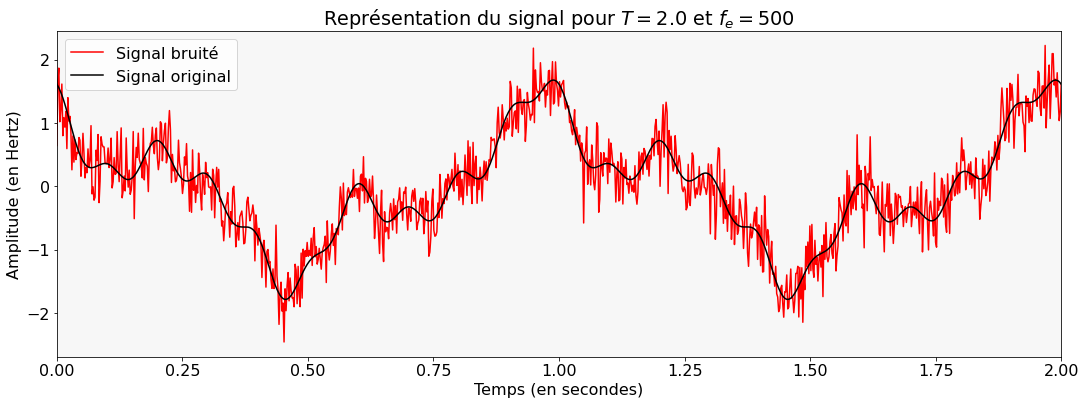

In [ ]:
# Initialisation des paramètres pour la représentation graphique.
T=2
fe=500
N=fe*T
points = np.linspace(0, T, N)
signal_bruite=sb(points)
signal_=s(points)

# Représentation graphique du signal bruité et non bruité.
plt.figure(figsize=(18,6)) # Taille du graphique
plt.rcParams['font.size'] = 16 # Taille de la police de texte
ax = plt.gca() ; ax.set_facecolor("#F7F7F7") ; ax.set(xlim=[0,2]) # Changements visuel
plt.title(label="Représentation du signal pour $T=2.0$ et $f_e=500$")
plt.xlabel("Temps (en secondes)")
plt.ylabel("Amplitude (en Hertz)")
plt.plot(points, signal_bruite, "red", label="Signal bruité")
plt.plot(points, signal_, "black",label="Signal original")
plt.legend()
plt.show()

###  **2.b) Spectre du signal discret et son amplitude dans $[0, \frac{f_e}{2}]$**

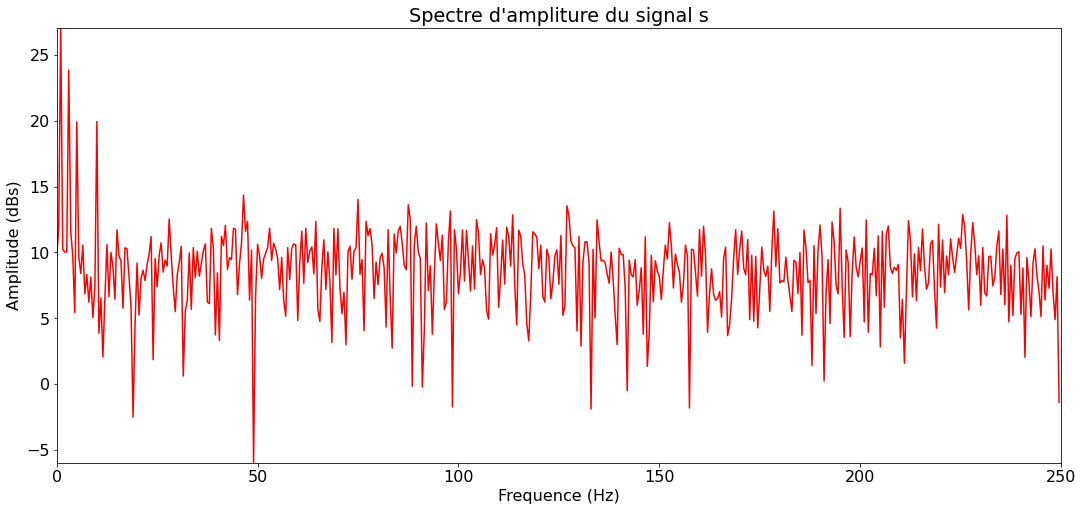

In [ ]:
x=signal_bruite

# Calcul du spectre
fft_signal = np.fft.fft(x)
amplitude_spectrum = np.abs(fft_signal)
spectrum = 10 * np.log10(amplitude_spectrum)
freqs = np.fft.fftfreq(N, 1 / fe)

# Affichage du spectre
plt.figure(figsize=(18,8))
plt.plot(freqs[0:500], spectrum[0:500],"red")
plt.axis([0,fe/2,spectrum.min(),spectrum.max()])
plt.xlabel('Frequence (Hz)')
plt.ylabel('Amplitude (dBs)')
plt.title("Spectre d'ampliture du signal s")
plt.show()

Nous constatons que le bruit se manifeste à toutes les fréquences. Cependant, il y a des pics en amplitude plus importants aux fréquences correspondant aux fonctions qui composent le signal. Deplus, la plage de fréquences d'échantillonnage contribuant à l'amplitude est réduite, ce qui indique un suréchantillonnage.

## **2.c) Filtre moyenneur**

Nous considérons le <u>filtre moyenneur</u> $$y[n]=\frac{x[n]-x[n-1]}{2}$$

###  **2.c.i) Tracé du module et de l'argument de la réponse fréquentielle**

Tout d'abord, introduisons un fonction que nous allons utiliser pour la suite qui permet de représenter la réponse fréquentielle.

In [ ]:
# Formule qui affiche le module et l'argument de la réponse fréquentielle.
def AfficherReponseFrequence(b,nf,title="",log10m=False):
	module, argument = ReponseFrequence(b, nf)
	fig, axs = plt.subplots(1, 2, figsize=(14, 6))
	plt.rcParams['font.size'] = 16
	fig.suptitle("Module et argument de la réponse fréquentielle "+r'$H(f/f_e)$'+" "+title, fontsize=18)
	plt.subplots_adjust(wspace=0.5)
	grid = np.linspace(0, 0.5, nf)
	axs[0].set_ylabel(r'$|H|$')
	if(log10m==True):
		module=np.log10(module)
		axs[0].set_ylabel(r'$log_{10}|H|$')

	axs[0].plot(grid,module,"orange",label="module")
	#axs[0].legend()
	axs[0].set_xlabel(r'$f/f_e$') ;

	axs[1].set_ylabel(r'$arg(H)$')
	axs[1].plot(grid,argument,"red",label="argument")
	axs[1].set_xlabel(r'$f/f_e$') ;
	#axs[1].legend()

	plt.show()

Ce filtre est traduit par les coefficients $ h[0] = \frac{1}{2}, \; h[1] = \frac{1}{2}, \; h[k] = 0 \; \text{pour} \; k \geq 2 $

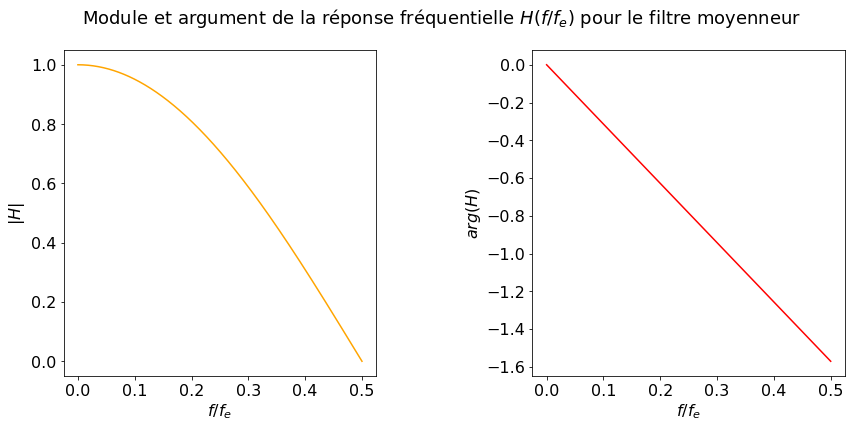

In [ ]:
T=2 ; nf=500 ; N=nf*T
h_moy = np.array([1/2,1/2])
AfficherReponseFrequence(h_moy,nf,"pour le filtre moyenneur")

###  **2.c.ii) Caractéristiques du filtre**

Nous observons que le filtre moyenneur est un filtre passe-bas dont la phase décroît linéairement avec la fréquence, ce qui indique que le délai de phase du filtre reste constant. Le module diminue selon une allure apparemment quadratique, atteignant un maximum pour $f/f_e=0$, et pénalise davantage les hautes fréquences que les basses fréquences.

###  **2.c.iii) Représentation du signal discret filtré**

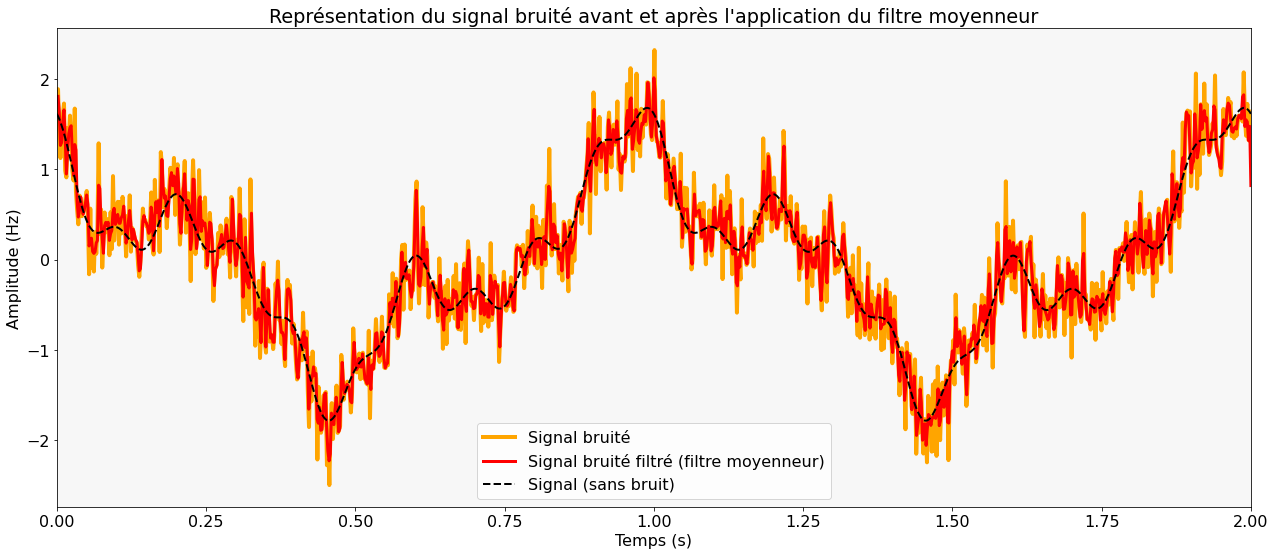

In [ ]:
filtre_moy=scipy.signal.convolve(signal_bruite,h_moy)[1:N+1]

#On ne considère pas te
te=1/fe
grid=te+np.arange(N)*te
# Représentation graphique.
plt.figure(figsize=(18,8)) # Taille du graphique
plt.rcParams['font.size'] = 16 # Taille de la police de texte
ax = plt.gca() ; ax.set_facecolor("#F7F7F7") ; ax.set(xlim=[0,2]) # Changement visuel
plt.title("Représentation du signal bruité avant et après l'application du filtre moyenneur")
plt.plot(points, signal_bruite,"orange",linewidth=4, label="Signal bruité")
# N'affiche pas te
plt.plot(grid, filtre_moy,"r",linewidth=3, label="Signal bruité filtré (filtre moyenneur)")
plt.plot(points, signal_,"--",color="black",linewidth=2, label="Signal (sans bruit)")
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude (Hz)')
plt.legend()
plt.tight_layout()
plt.show()

Le lissage atténue les hautes fréquences et conserve les tendances générales avec un retard. L’efficacité du filtrage augmente avec un ordre plus élevé, au prix d’un lissage plus marqué.

##  **2.d) Filtre gaussien**

Nous considérons un filtre passe-bas gaussien. C'est-à-dire un filtre dont la réponse impulsionnelle est une gaussienne.

Rappelons la fonction gaussienne $f(t)=\frac{1}{\sigma \sqrt{2 \pi}} exp(-\frac{t^2}{2 \sigma^2})$

Nous choisissons une longueur de réponse impaire $N=2Q+1$ afin de centrer la réponse impulsionnelle sur l'indice k=Q.

Aussi, nous prenons $\sigma=\frac{Q}{\sqrt{-2 log \varepsilon}}$ et puis nous normalisons la réponse fréquentielle.

In [ ]:
# Fonction de Gauss
def gaussian(t,sigma):
	return( np.exp(-(math.pow(t,2))/(2*math.pow(sigma,2)))/(sigma*math.sqrt(2*np.pi)))
gaussian=np.vectorize(gaussian, excluded='sig')

###  **2.d.i) Tracé du module et de l'argument de la réponse fréquentielle pour $P=10$ et $\varepsilon = 0.01$**

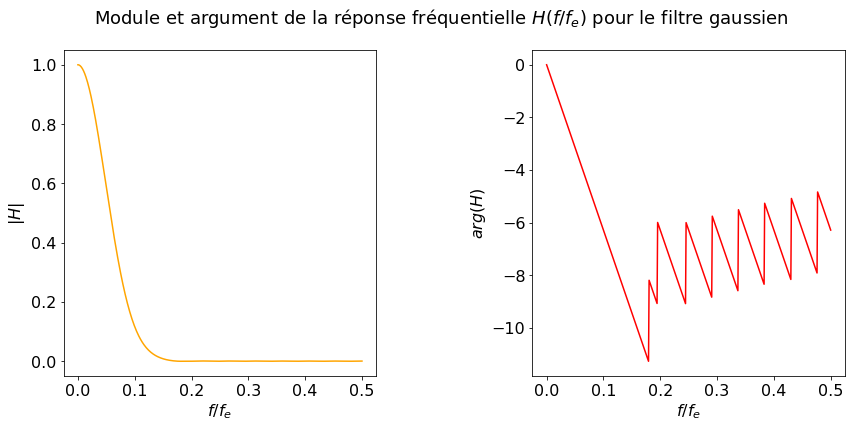

In [ ]:
# Longueur de la réponse
P=10
N=2*P+1
epsilon=0.01
sigma=P/math.sqrt(-2*math.log(epsilon))

# Transformations en vecteurs de dimension N
k=np.array(range(N))
Q=np.array([P]*N)

b_gauss=gaussian(k-Q,sigma)
# Normalisation
norm=np.sum(b_gauss)
b_gauss=b_gauss/norm

# On utilise l'option qui normalise dans la fonction d'affichage
AfficherReponseFrequence(b_gauss,fe,"pour le filtre gaussien")


###  **2.d.ii) Caractéristiques du fitre**

La réponse fréquentielle d'un filtre gaussien est également gaussienne, ce qui entraîne une atténuation progressive et uniforme des hautes fréquences. Par ailleurs, la phase décroît linéairement sur la bande passante avant d'augmenter très légèrement avec des oscillations, de manière discontinue. Comparé au filtre moyenneur, le filtre gaussien est moins fidèle au signal en termes de phase, mais il présente une meilleure capacité d'atténuation des hautes fréquences.

###  **2.d.iii) Tracé du module et de l'argument de la réponse fréquentielle pour $P=10$ et $\varepsilon = 0.01$**

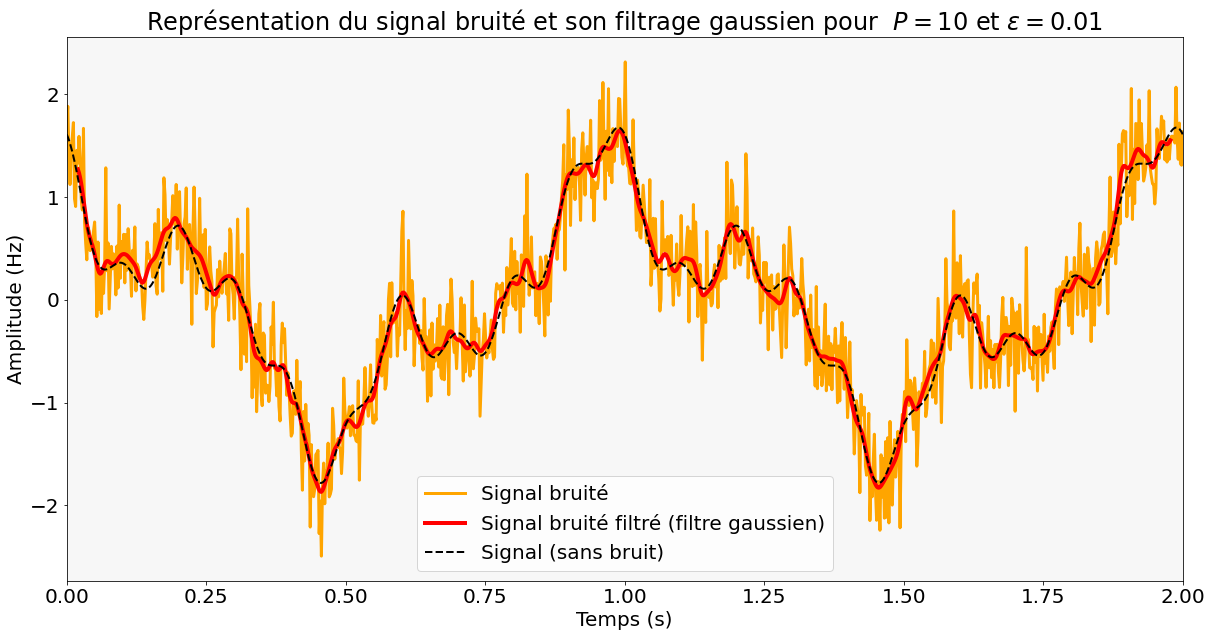

In [ ]:
filtre_gauss=scipy.signal.convolve(signal_bruite,b_gauss,mode='valid')
te=1/fe
grid=te*(P+np.arange(filtre_gauss.size))
# Représentation graphique.
plt.figure(figsize=(20,10)) # Taille du graphique
plt.rcParams['font.size'] = 20 # Taille de la police de texte
ax = plt.gca() ; ax.set_facecolor("#F7F7F7") ; ax.set(xlim=[0,2]) # Changement visuel
plt.title("Représentation du signal bruité et son filtrage gaussien pour  $P=10$ et $\\varepsilon = 0.01$")
plt.plot(points, signal_bruite,"orange",linewidth=3, label="Signal bruité")
plt.plot(grid, filtre_gauss,"r",linewidth=4, label="Signal bruité filtré (filtre gaussien)")
plt.plot(points, signal_,"--",color="black",linewidth=2, label="Signal (sans bruit)")
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude (Hz)')
plt.legend()
plt.show()

Après filtrage, le signal devient nettement plus lisse, avec une réduction significative du bruit par rapport à la version initiale bruitée. Ce qui distingue le filtre gaussien, c’est sa capacité remarquable à atténuer le bruit tout en respectant la forme générale du signal. Contrairement au filtre moyenneur, il réussit à mieux conserver les détails subtils du signal tout en éliminant efficacement les composantes indésirables des hautes fréquences.

Nous appliquons la convolution avec l'option 'valid', il y a $P$ points qui ne sont pas filtré en début et en fin du signal soit $2P$ points au final.

## **2.e) Filtre sinus cardinal**

Nous considérons un fitre avec une impulsion qui est un sinus cardinal : $$b[k]=2asinc(2  (k-Q)a)\quad \text{avec}\; a=f_c/f_e \leq 1/2 \text{  et  } f_c \text{ la fréquence de coupure}$$

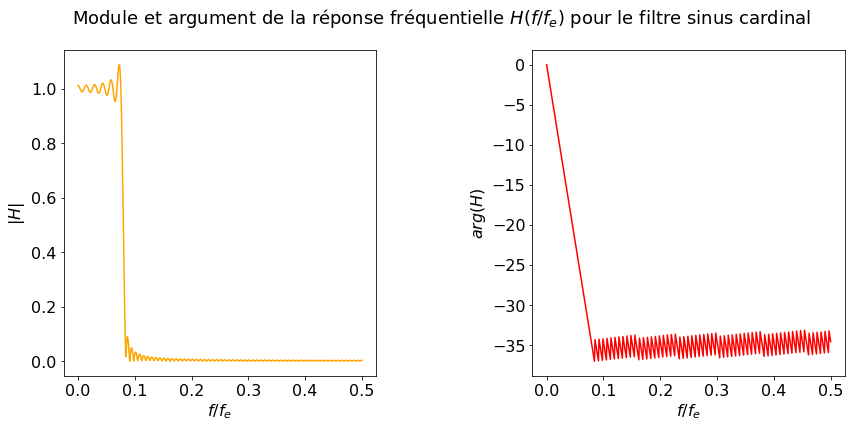

In [ ]:
fc=40 ; fe=500
P=70
N=2*P+1

k=np.array(range(N))
Q=P
a=fc/fe
b_sinc=2*a*np.sinc(2*(k-Q)*a)

AfficherReponseFrequence(b_sinc,fe,"pour le filtre sinus cardinal")

Le filtre sinc, semblable au filtre gaussien, se démarque par une sélectivité plus élevée, offrant une transition plus nette entre la bande passante et la bande atténuée. Il atténue les hautes fréquences de manière variable en fonction de la fréquence de coupure. Cette précision accrue s’accompagne toutefois de petites ondulations, tant dans la bande passante que dans la bande atténuée, en raison de la nature oscillatoire du sinus cardinal. Sa phase est linéaire dans la bande passante mais elle devient ensuite discontinue avec des oscillations proches d’une valeur fixe.

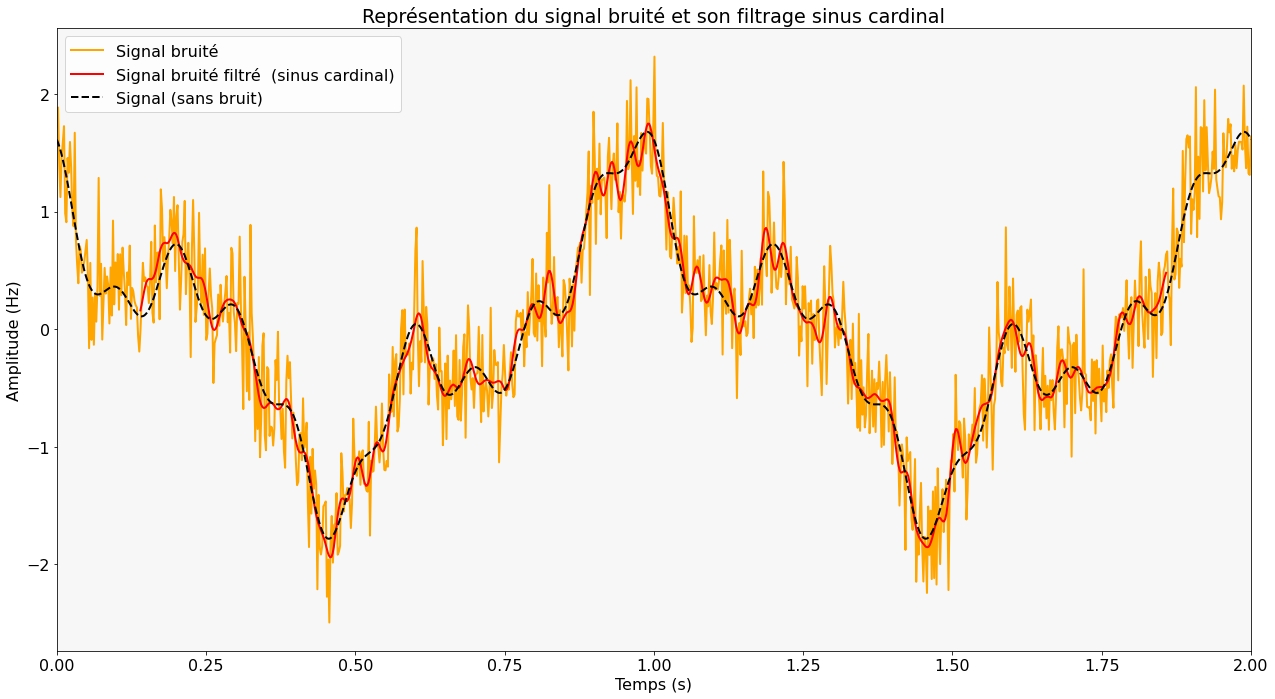

In [ ]:
filtre_sinc=scipy.signal.convolve(signal_bruite,b_sinc,mode='valid')
te=1/fe
B=b_gauss.size-1
grid=te*(P+np.arange(filtre_sinc.size))
# Représentation graphique.
plt.figure(figsize=(18,10)) # Taille du graphique
plt.rcParams['font.size'] = 16 # Taille de la police de texte
ax = plt.gca() ; ax.set_facecolor("#F7F7F7") ; ax.set(xlim=[0,2]) # Changement visuel
plt.title("Représentation du signal bruité et son filtrage sinus cardinal")
plt.plot(points, signal_bruite,"orange",linewidth=2, label="Signal bruité")
plt.plot(grid, filtre_sinc,"r",linewidth=2, label="Signal bruité filtré  (sinus cardinal)")
plt.plot(points, signal_,"--",color="black",linewidth=2, label="Signal (sans bruit)")
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude (Hz)')
plt.legend()
plt.tight_layout()
plt.show()

Le filtre sinus cardinal est très précis pour ajuster les amplitudes des fréquences, notamment en coupant efficacement les hautes fréquences tout en préservant les basses. Cependant, sa mise en œuvre peut être compliquée, et il n’est pas toujours le plus adapté en pratique. Par exemple, à cause de sa nature oscillatoire, il peut introduire des ondulations dans la bande passante et la bande atténuée, ce qui peut poser des problèmes dans des situations où une grande stabilité du signal est requise.

## **2.f) Filtre dérivateur**

Considérons le filtre dérivateur défini par $y[n]=\frac{x[n]-x[n-1]}{t_e}$

### **2.f.i) Tracé de la réponse fréquentielle et caractéristiques du filtre**

Nous choisissons $f_e=100$, $t_e=1/f_e$.

Ainsi, nous avons pour coefficients $h[0]=\frac{1}{f_e}$ et $h[1]=-\frac{1}{f_e}$.

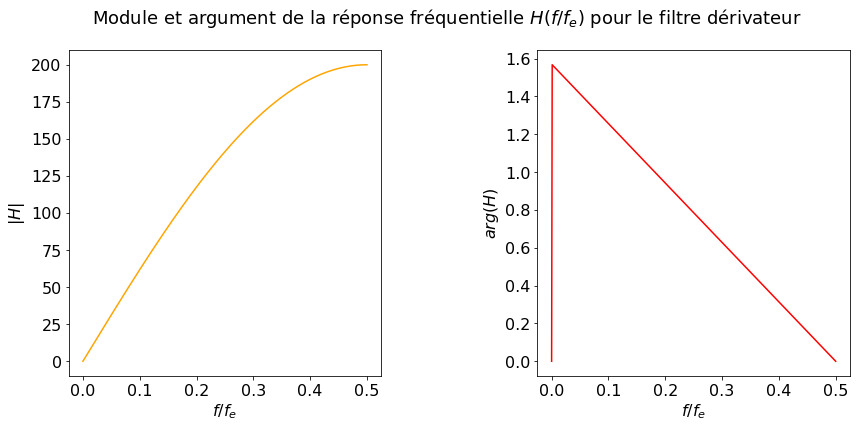

In [ ]:
f_e=100
t_e=1/f_e
b_deriv=np.array([1/t_e,-1/t_e])
nf=500

AfficherReponseFrequence(b_deriv,nf,"pour le filtre dérivateur")

Ce filtre amplifie davantage les hautes fréquences que les basses. Le gain augmente de manière "quadratique" avec la fréquence, ce qui en fait un filtre passe-haut. Sa phase présente un saut initial, puis décroît linéairement avec la fréquence.

### **2.f.ii) Représentation du signal bruité filtré**

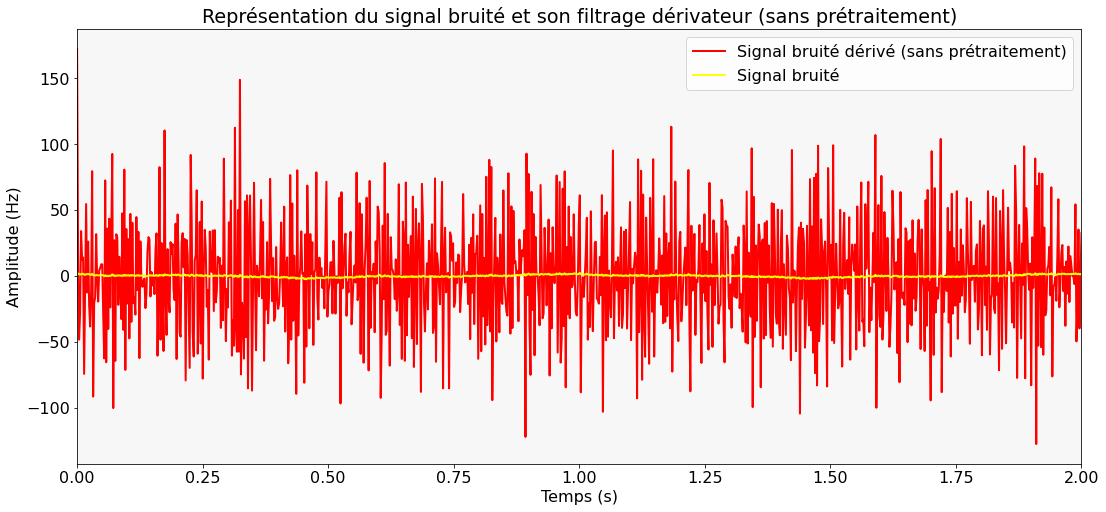

In [ ]:
filtre_deriv=scipy.signal.convolve(signal_bruite,b_deriv,mode='same')
grid=np.linspace(0,T,filtre_deriv.size)
# Représentation graphique.
plt.figure(figsize=(18,8)) # Taille du graphique
plt.rcParams['font.size'] = 16 # Taille de la police de texte
ax = plt.gca() ; ax.set_facecolor("#F7F7F7") ; ax.set(xlim=[0,2]) # Changement visuel
plt.title("Représentation du signal bruité et son filtrage dérivateur (sans prétraitement)")
plt.plot(grid, filtre_deriv,"r",linewidth=2, label="Signal bruité dérivé (sans prétraitement)")
plt.plot(points, signal_bruite,"yellow",linewidth=2, label="Signal bruité")
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude (Hz)')
plt.legend()
plt.show()

Le filtre dérivateur amplifie tellement le bruit qu'il masque complètement le signal pertinent. Cette forte amplification est due à la nature passe-haut du filtre, qui intensifie les hautes fréquences où se situe principalement le bruit. En calculant la dérivée du signal, le dérivateur accentue encore davantage les fluctuations rapides typiques du bruit, rendant le signal difficilement identifiable.

### **2.f.iii) Représentation du signal bruité filtré avec prétraitement gaussien**

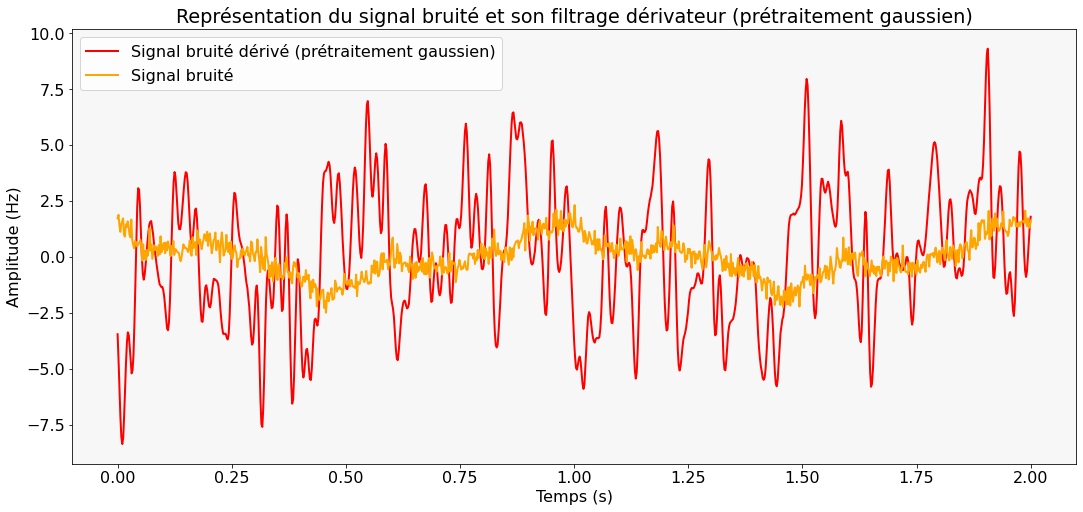

In [ ]:
#On utilise le filtre gaussien
filtre_deriv=scipy.signal.convolve(filtre_gauss,b_deriv,mode='valid')
grid=np.linspace(0,T,filtre_deriv.size)
# Représentation graphique.
plt.figure(figsize=(18,8)) # Taille du graphique
plt.rcParams['font.size'] = 16 # Taille de la police de texte
ax = plt.gca() ; ax.set_facecolor("#F7F7F7") ; #ax.set(xlim=[0,2]); ax.set(ylim=[-3,3])# Changement visuel
plt.title("Représentation du signal bruité et son filtrage dérivateur (prétraitement gaussien)")
plt.plot(grid, filtre_deriv,"r",linewidth=2, label="Signal bruité dérivé (prétraitement gaussien)")
plt.plot(points, signal_bruite,"orange",linewidth=2, label="Signal bruité")
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude (Hz)')
plt.legend()
plt.show()

Un prétraitement permet d'obtenir un meilleur résultat en éliminant une partie du bruit qui aurait été accentuée sans cette étape. Cependant, le filtre conserve sa capacité à absorber les basses fréquences, ce qui le rend peu pertinent dans ce cas d'utilisation.

# **3) Quelques exemples de filtres RIF à phase linéaire**

Nous sommes intéressés par la construction de filtres à réponse impulsionnelle finie de la forme : $$H_e(f)=e^{-2 i \pi  f Q / f_e} R(f), \quad R(f)=\sum_{k=-Q}^Q r[k]e^{2 i \pi k f/ f_e} \quad \text{avec} \; r[k]=r[-k]$$

Ainsi, nous avons la réponse fréquentielle suivante : $$H_e(f)=\sum_{n=0}^{2Q} h[n]e^{- 2 i \pi  f n / f_e}, \quad h[n]=r[n-Q], \; \; n=0,\ldots,2Q$$

Donnons les coefficients de Fourier pour différents filtres standards :
* Filtre passe-bas : $R(f)=1 \;\text{si} \; f \in [0,a] \; \text{et} \; 0 \; \text{sinon}$ $$r[k]=2asinc(k2a) \quad \text{avec} \; sinc(x)=\frac{sin(\pi x)}{\pi x}$$
* Filtre passe-haut : $R(f)=1 \;\text{si} \; f \in [a,1/2] \; \text{et} \; 0 \; \text{sinon}$ $$r[0]=1-2a, \quad r[k]=-2a sinc(k 2 a)$$
* Filtre passe-bande : $R(f)=1 \;\text{si} \; f \in [a,b] \; \text{et} \; 0 \; \text{sinon}$  $$r[0]=2(b-a), \quad r[k]=\frac{sin(2 k b \pi)- sin(2 k a \pi)}{k \pi}$$
* Fitre coupe-bande : $R(f)=0 \;\text{si} \; f \in [a,b] \; \text{et} \; 0 \; \text{sinon}$  $$r[0]=2(a-b)+1, \quad r[k]=\frac{sin(2 k a \pi)- sin(2 k b \pi) }{k \pi}$$

### 3.a) Implémentation d'une fonction qui implemente un filtre général

Nous définissons la fonction **filtreRIFgeneral** qui prend en entrée un filtre général d'ordre **P** ayant pour coefficients **g** et un type de fenêtre dans **fenêtre**.

In [ ]:
def filtreRIFgeneral(g,P,fenetre):
	w=signal.windows.get_window(fenetre,P,True)
	filtre=g*w
	return filtre

### 3.b) Implémentation d'une fonction qui implemente les différents types de filtres

Nous définissons la fonction **filtreRIF** qui prend en entrée :
* le **type** de filtre : **"PBas"** pour passe-bas, **"PHaut"** pour passe-haut, **"PBande"** pour passe-bande, **"CBande"** pour coupe-bande.
* **a** et **b** sont les fréquences de coupure (divisées par **f_e**).
* les types de fenêtre sont dans **get_window**.

In [ ]:
def filtreRIF(type,a,b,P,fenetre):
	M=2*P+1
	r=np.array([0]*(2*P+1))
	k=np.array(range(1,P+1))
	if(type=="PBas"):
			e=2*a*np.sinc(k*2*a)

			r=np.flip(e)
			r=np.append(r,[2*a],axis=0)
			r=np.append(r,e,axis=0)

			r=filtreRIFgeneral(r,M,fenetre)

	elif(type=="PHaut"):
			e=-2*a*sinc(k*2*a)

			r=np.flip(e)
			r=np.append(r,[1-2*a],axis=0)
			r=np.append(r,e,axis=0)

			r=filtreRIFgeneral(r,M,fenetre)

	elif(type=="PBande"):
			e=(np.sin(2*k*b*np.pi)-np.sin(2*k*a*np.pi))/(k*np.pi)

			r=np.flip(e)
			r=np.append(r,[2*(b-a)],axis=0)
			r=np.append(r,e,axis=0)

			r=filtreRIFgeneral(r,M,fenetre)
	elif(type=="CBande"):
			e=(np.sin(2*k*a*np.pi)-np.sin(2*k*b*np.pi))/(k*np.pi)

			r=np.flip(e)
			r=np.append(r,[2*(a-b)+1],axis=0)
			r=np.append(r,e,axis=0)

			r=filtreRIFgeneral(r,M,fenetre)
	else:
			raise ValueError("Type de filtre non reconnu.")
	return r

## **3.c) Test des différents filtres**

Nous considérons le signal : $$s(t)=cos(2 \pi t) + 0.5 cos(4 \pi t - 1.0) + 0.25 cos(6 \pi t + 0.6)$$
pour une fréquence d'échantillonnage $f_e=50$ dans $[0,1]$.

In [ ]:
def s_2(t):
	signal=np.cos(2*np.pi*t)+0.5*np.cos( 4*np.pi*t -1)+0.25*np.cos( 6*np.pi*t + 0.6)
	return signal

### c.i) Filtre passe-bas

Nous changeons l'échelle des graphiques du module pour mieux observer les variations.

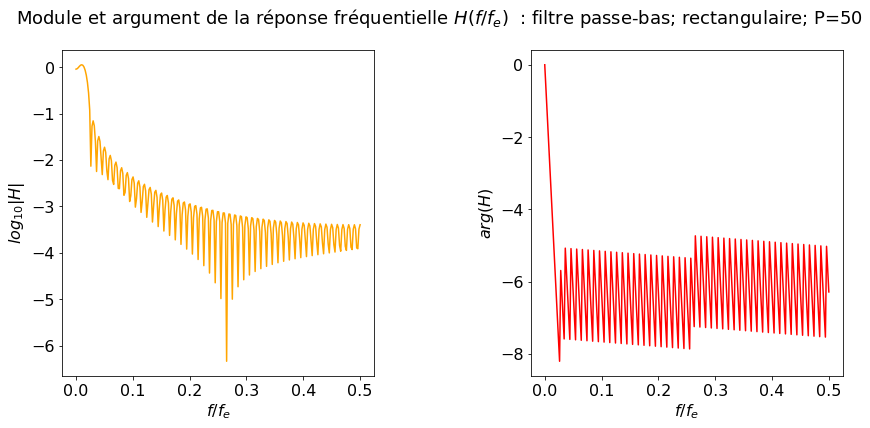

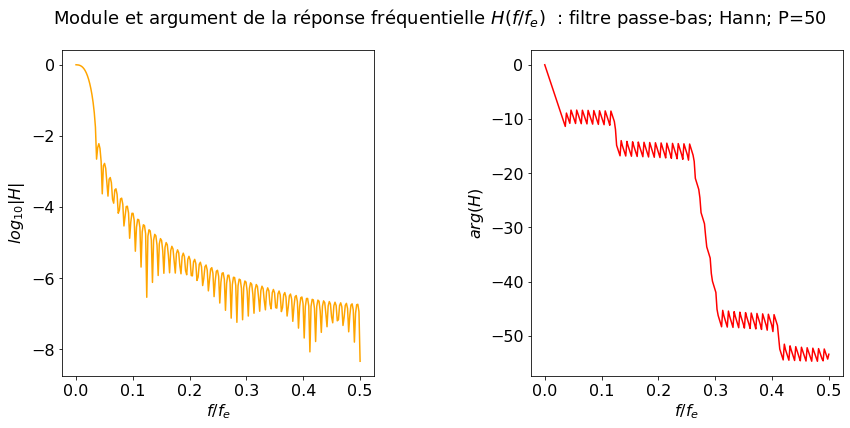

In [ ]:
fc=1
T=5
fe=50
te=1/fe
nf=fe*T
P=50
points_2 = np.linspace(0, T, nf)
signal_2=s_2(points_2)

h_rect=filtreRIF("PBas",fc/fe,1,P,'rect')
h_hann=filtreRIF("PBas",fc/fe,1,P,'hann')

AfficherReponseFrequence(h_rect,nf,title=" : filtre passe-bas; rectangulaire; P="+str(P),log10m=True)
AfficherReponseFrequence(h_hann,nf,title=" : filtre passe-bas; Hann; P="+str(P),log10m=True)

Nous remarquons que le filtre passe-bas rectangulaire laisse passer plus de hautes fréquences que le filtre de Hann, car ses lobes secondaires (dans la bande atténuée) sont plus élevés, ce qui entraîne une atténuation moins efficace des hautes fréquences. Par rapport au filtre rectangulaire, le filtre de Hann atténue de manière plus progressive et moins brusque, tout en réduisant davantage les hautes fréquences.

En ce qui concerne la phase, nous observons que celle-ci est linéaire pour les deux filtres dans la bande passante (cette bande est moins visible en raison du changement d’échelle), ce qui permet de conserver la forme des signaux dont les harmoniques se trouvent dans cette bande. Cependant, dans la bande atténuée, la phase du filtre passe-bas rectangulaire oscille autour d’une même valeur, tandis que celle du filtre passe-bas de Hann suit une trajectoire globalement linéaire, avec quelques oscillations ponctuelles sur cette même bande.

Nous créons une fonction permettant d'afficher de manière pratique le signal filtré selon le type voulu.

In [ ]:
def AfficherRIF(sign,h_1,title_1="",h_2=None,title_2=""):
	if(h_2 is not None):
		pts=np.linspace(0,T,sign.size)
		fig, axs = plt.subplots(1, 2, figsize=(18, 4))
		plt.rcParams['font.size'] = 14
		plt.subplots_adjust(wspace=0.2)

		filtre_RIF_1=scipy.signal.convolve(sign,h_1,mode='valid')
		#grid_1=np.linspace(0,T,filtre_RIF_1.size)
		grid_1=P*te+np.arange(filtre_RIF_1.size)*te
		axs[0].set_title(title_1)
		axs[0].plot(pts, sign,color="black",linewidth=2, label="Signal original")
		axs[0].plot(grid_1, filtre_RIF_1,"r",linewidth=2, label="Signal filtré")
		axs[0].legend()
		axs[0].set_xlabel('Temps (s)')
		axs[0].set_ylabel('Amplitude (Hz)')

		filtre_RIF_2=scipy.signal.convolve(sign,h_2,mode='valid')
		#grid_2=np.linspace(0,T,filtre_RIF_2.size)
		grid_2=P*te+np.arange(filtre_RIF_2.size)*te
		axs[1].set_title(title_2)
		axs[1].plot(pts, sign,color="black",linewidth=2, label="Signal original")
		axs[1].plot(grid_2, filtre_RIF_2,"r",linewidth=2, label="Signal filtré")
		axs[1].legend()
		axs[1].set_xlabel('Temps (s)')
		axs[1].set_ylabel('Amplitude (Hz)')
		plt.tight_layout()
		plt.show()

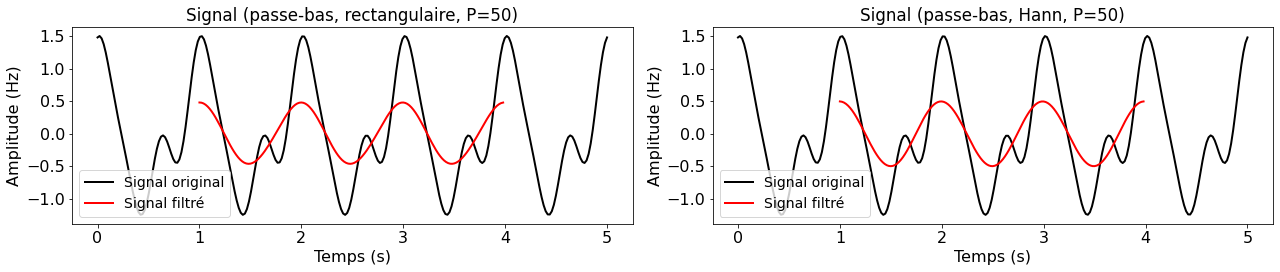

In [ ]:
AfficherRIF(signal_2,h_1=h_rect,h_2=h_hann,title_1="Signal (passe-bas, rectangulaire, P="+str(P)+")",title_2="Signal (passe-bas, Hann, P="+str(P)+")")

Les deux filtres atténuent les amplitudes les plus élevées, ce qui réduit l’amplitude du signal filtré à une plage comprise entre -0,5 et 1 Hz, alors que le signal original varie entre -1 et 1,5 Hz. Cette atténuation affecte également les tendances globales du signal, car les composantes de haute fréquence, trop importantes par rapport aux basses fréquences, sont diminuées, ce qui modifie la structure globale du signal.

### Pour P=10

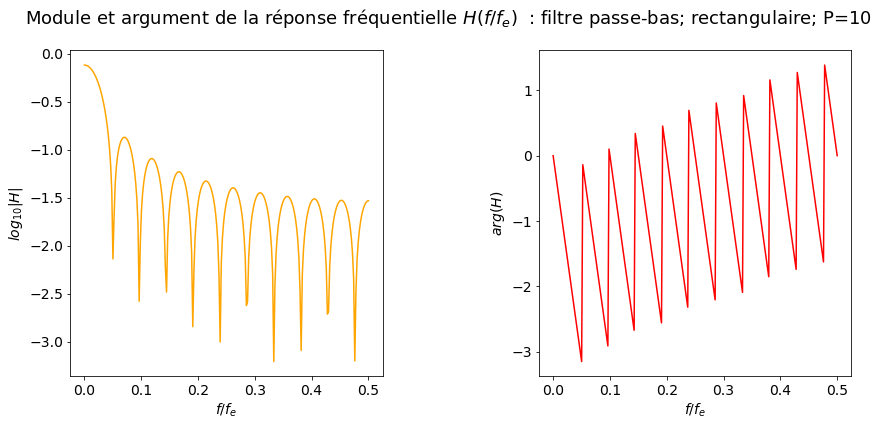

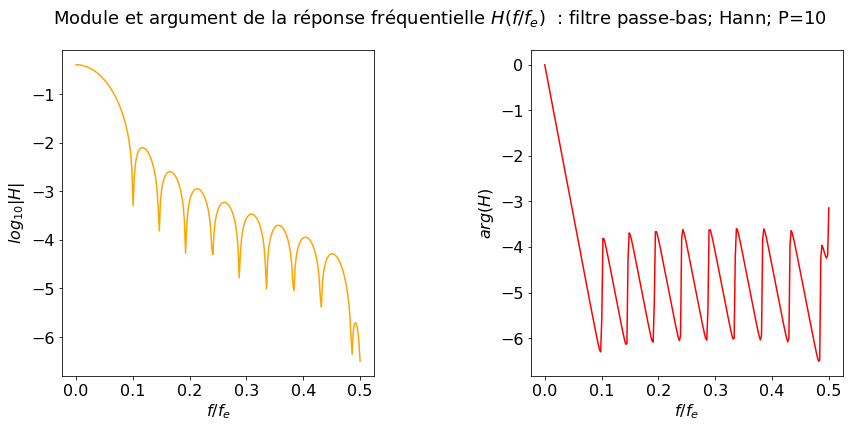

In [ ]:
P=10
h_rect=filtreRIF("PBas",fc/fe,1,P,'rect'); h_hann=filtreRIF("PBas",fc/fe,1,P,'hann')

AfficherReponseFrequence(h_rect,nf,title=" : filtre passe-bas; rectangulaire; P="+str(P),log10m=True)
AfficherReponseFrequence(h_hann,nf,title=" : filtre passe-bas; Hann; P="+str(P),log10m=True)

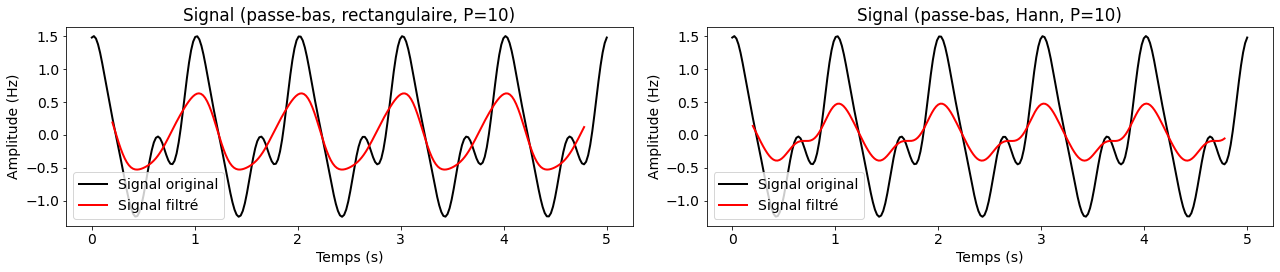

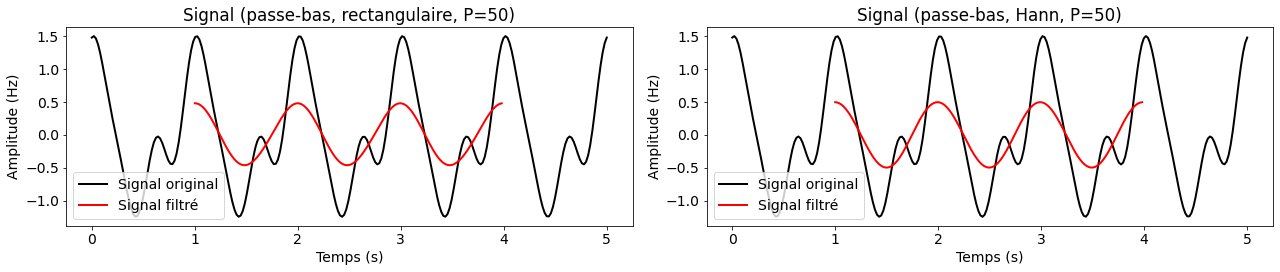

In [ ]:
P=10; h_rect=filtreRIF("PBas",fc/fe,1/fe,P,'rect'); h_hann=filtreRIF("PBas",fc/fe,1/fe,P,'hann')
AfficherRIF(signal_2,h_1=h_rect,h_2=h_hann,title_1="Signal (passe-bas, rectangulaire, P="+str(P)+")",title_2="Signal (passe-bas, Hann, P="+str(P)+")")


P=50; h_rect=filtreRIF("PBas",fc/fe,1/fe,P,'rect'); h_hann=filtreRIF("PBas",fc/fe,1/fe,P,'hann')
AfficherRIF(signal_2,h_1=h_rect,h_2=h_hann,title_1="Signal (passe-bas, rectangulaire, P="+str(P)+")",title_2="Signal (passe-bas, Hann, P="+str(P)+")")

Nous observons qu’un décalage important apparaît au début et à la fin des échantillons lorsque P augmente. Cela peut poser problème pour les signaux non périodiques, car cela risque de provoquer une perte d’information. Une augmentation de la dimension du filtre améliore l'atténuation des fréquences hors bande pour les deux types de fenêtres. Cependant, la fenêtre de Hann offre un meilleur contrôle des lobes atténués et produit un signal filtré plus fluide, tandis que la fenêtre rectangulaire procure une coupure plus nette, mais avec une atténuation des hautes fréquences moins efficace.  De plus, plus l’indice P est grand, plus les hautes fréquences sont atténuées.


Examinons les différents modes de convolution pour **scipy.signal.convolve**, il y a trois modes de convolution :
* **full** : correspond à la convolution linéaire discrète complète des entrées, avec une longueur égale à la somme des longueurs des deux signaux moins un.
* **same** : génère une sortie de même taille que l'échantillon du signal, centrée par rapport au mode "full", tout en incluant la convolution des P premiers et derniers points en s'appuyant sur une partie de la réponse impulsionnelle.
* **valid** : restreint le calcul de la convolution aux points valides, ce qui signifie que le premier point est calculé à partir des $2P+1$ premiers points de l'échantillon et le dernier point à partir des $2P+1$ derniers points, tout en exigeant que l'un des deux signaux soit au moins aussi grand que l'autre dans chaque dimension.

Voyons graphiquement ce que donne les modes **same** et **valid** pour un signal :

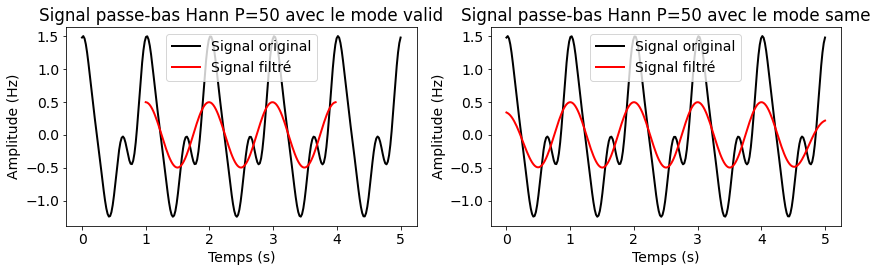

In [ ]:
pts=np.linspace(0,T,signal_2.size)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
plt.rcParams['font.size'] = 14
plt.subplots_adjust(wspace=0.2)

filtre_RIF_1=scipy.signal.convolve(signal_2,h_hann,mode='valid')
#grid_1=np.linspace(0,T,filtre_RIF_1.size)
grid_1=P*te+np.arange(filtre_RIF_1.size)*te
axs[0].set_title("Signal passe-bas Hann P=50 avec le mode valid")
axs[0].plot(pts, signal_2,color="black",linewidth=2, label="Signal original")
axs[0].plot(grid_1, filtre_RIF_1,"r",linewidth=2, label="Signal filtré")
axs[0].legend()
axs[0].set_xlabel('Temps (s)')
axs[0].set_ylabel('Amplitude (Hz)')

filtre_RIF_2=scipy.signal.convolve(signal_2,h_hann,mode='same')
grid_2=np.linspace(0,T,filtre_RIF_2.size)
axs[1].set_title("Signal passe-bas Hann P=50 avec le mode same")
axs[1].plot(pts, signal_2,color="black",linewidth=2, label="Signal original")
axs[1].plot(grid_2, filtre_RIF_2,"r",linewidth=2, label="Signal filtré")
axs[1].legend()
axs[1].set_xlabel('Temps (s)')
axs[1].set_ylabel('Amplitude (Hz)')
plt.tight_layout()
plt.show()

### c.ii) Filtre passe-bande et coupe-bande

En premiers lieu, regardons les réponses impulsionnelles des filtres passe-bande et leurs applications au signal ave $a=1.5$, $b=2.5$ et $P=50$.

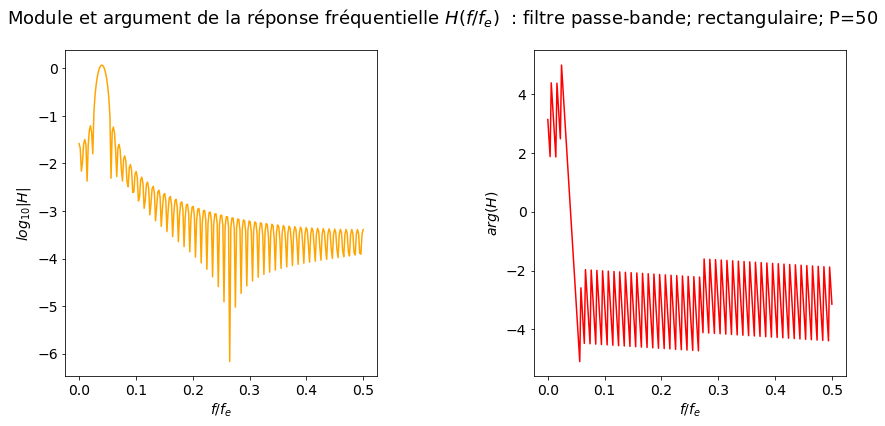

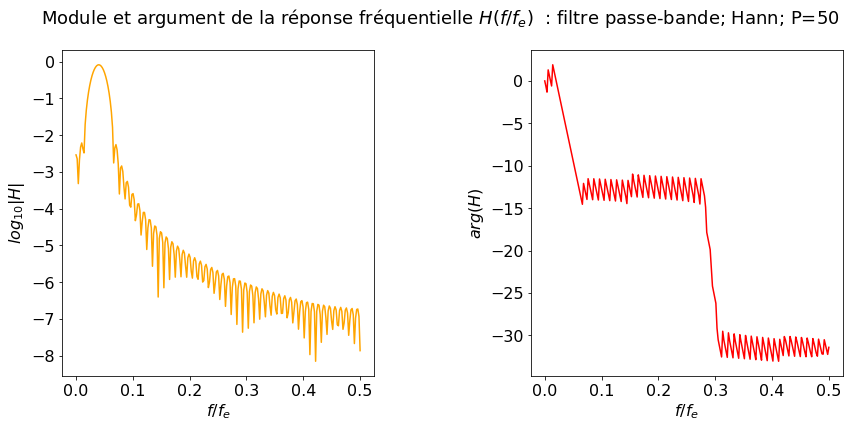

In [ ]:
P=50 ; a= 1.5; b=2.5
h_rect_PB=filtreRIF("PBande",a/fe,b/fe,P,'rect')
h_hann_PB=filtreRIF("PBande",a/fe,b/fe,P,'hann')

AfficherReponseFrequence(h_rect_PB,nf,title=" : filtre passe-bande; rectangulaire; P=50",log10m=True)
AfficherReponseFrequence(h_hann_PB,nf,title=" : filtre passe-bande; Hann; P=50",log10m=True)


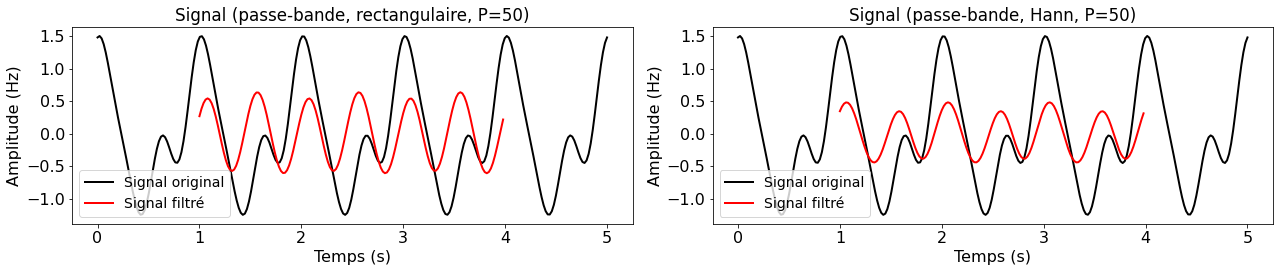

In [ ]:
AfficherRIF(signal_2,h_1=h_rect_PB,h_2=h_hann_PB,title_1="Signal (passe-bande, rectangulaire, P="+str(P)+")",title_2="Signal (passe-bande, Hann, P="+str(P)+")")

Nous observons un décalage de période entre les oscillations des signaux filtré et non filtré. De plus, le filtrage à l’aide d’une fenêtre rectangulaire produit un signal avec des variations d'amplitude plus prononcées. Cependant, dans les deux cas, les signaux filtrés se composent de deux oscillations légèrement différentes avec une amplitude similaire.

Les observations précédemment formulées restent valables : le filtre passe-bande utilisant une fenêtre de Hann atténue davantage les hautes fréquences de manière progressive et sans à-coups, tandis que la fenêtre rectangulaire génère des transitions plus abruptes. Enfin, le retard de phase est plus marqué avec la fenêtre de Hann.

Faisons de même pour les filtres coupe-bande.

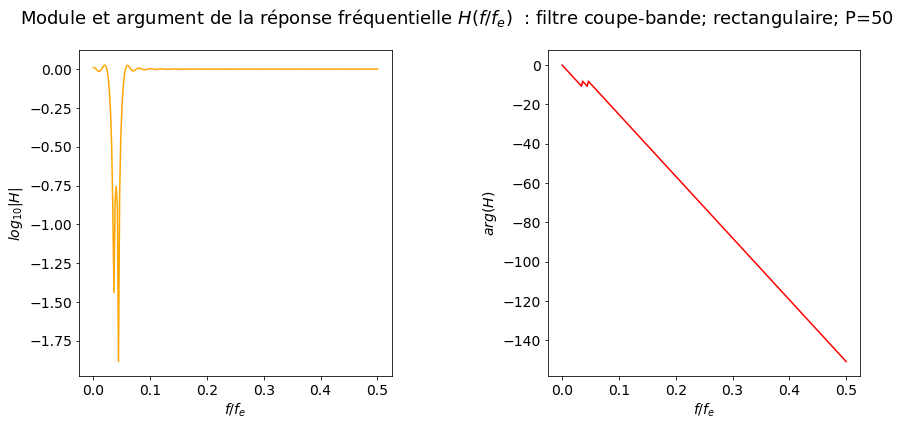

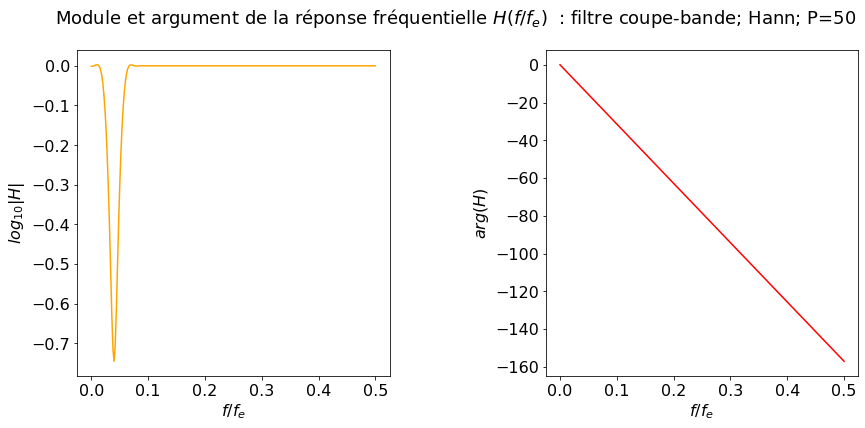

In [ ]:
P=50 ; a= 1.5; b=2.5
h_rect_CB=filtreRIF("CBande",a/fe,b/fe,P,'rect')
h_hann_CB=filtreRIF("CBande",a/fe,b/fe,P,'hann')
AfficherReponseFrequence(h_rect_CB,nf,title=" : filtre coupe-bande; rectangulaire; P=50",log10m=True)
AfficherReponseFrequence(h_hann_CB,nf,title=" : filtre coupe-bande; Hann; P=50",log10m=True)

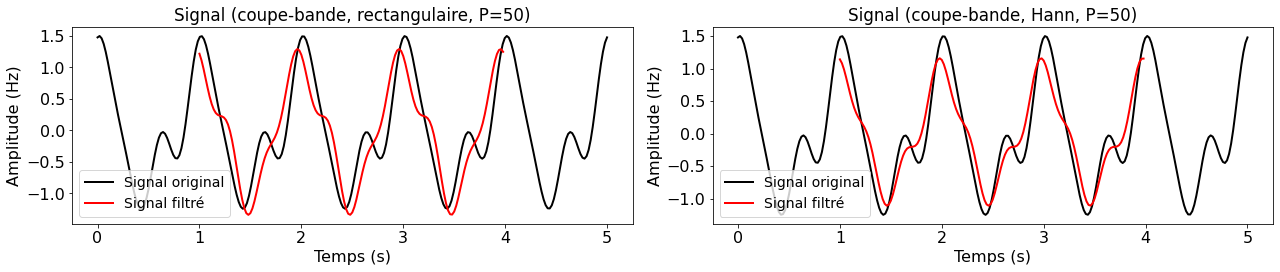

In [ ]:
AfficherRIF(signal_2,h_1=h_rect_CB,h_2=h_hann_CB,title_1="Signal (coupe-bande, rectangulaire, P="+str(P)+")",title_2="Signal (coupe-bande, Hann, P="+str(P)+")")

Nous observons que les deux filtres produisent un signal filtré qui se rapproche fortement du signal original, avec des variations d’amplitude similaires entre le signal filtré et le signal d’origine. Cependant, un déphasage est présent dans les deux cas. Les phases des deux filtres suivent une tendance approximativement linéaire, ce qui indique un délai constant par rapport au signal.

Les réponses fréquentielles des filtres coupe-bande diffèrent considérablement de celles observées précédemment. En effet, les fréquences atténuées se concentrent sur une plage très spécifique des basses fréquences (entre 0.0 et 0.1). Les fréquences supérieures à 0.1 et une partie des fréquences très proches de 0 sont préservées. Cette atténuation crée un creux dans la plage fréquentielle ciblée, réduisant ainsi l’amplitude du signal dans cette zone.

Nous remarquons également que les deux filtres introduisent des perturbations dans le signal filtré, en particulier dans la partie descendante de chaque oscillation, où nous pouvons observer des perturbations qui ne sont pas présentes par rapport au signal initial.